# Partie Amelioration - Architecture MS-SE-BiGRU-Attn

## 1. Objectif du notebook

Proposer une **architecture alternative** au MCTNet de Partie 1 et 2, et la comparer rigoureusement :
- **Section A** : MS-SE-BiGRU-Attn sur S2 seul vs Partie 1 (MCTNet S2 only)
- **Section B** : MS-SE-BiGRU-Attn sur 5 configs avec covariables vs Partie 2 (MCTNet+Cov)

**Memes CSV, meme split (240/60/reste), meme test set** -> ecarts attribuables uniquement a l'architecture.

---

## 2. Limitations identifiees de MCTNet dans Partie 1 et 2

### 2.1 Limitations architecturales

| # | Limitation | Consequence observee |
|---|------------|----------------------|
| 1 | **d_model = n_bands** (10 pour S2 seul) | Representation interne tres etroite -> faible capacite expressive |
| 2 | **nhead = 2** dans le Transformer | Tres peu de tetes d'attention -> peu de patterns temporels diversifies |
| 3 | **CNN avec kernel fixe (k=3)** | Capture une seule echelle phenologique -> manque les motifs longs (saisonniers) |
| 4 | **Pas de channel attention** | Toutes les bandes traitees egalement -> pas de mise en avant de NIR/SWIR (les plus informatives) |
| 5 | **GlobalMaxPool final** | Perte d'info temporelle (quand survient le pic NDVI ?) |
| 6 | **CTFusion identique a chaque stage** | Pas de specialisation low-level (texture) vs high-level (semantique) |
| 7 | **Dropout 0.2 seul** | Regularisation faible pour petit train (240 samples/cls) |
| 8 | **Capacite scale lineairement avec n_bands** | Pour S2_all (18 bandes), d=18 reste tres etroit |

### 2.2 Consequences observees dans les resultats

- **CA Partie 1 (S2 only)** : OA = 81.83% -> erreurs concentrees sur Almonds/Pistachios (peremes proches)
- **CA Partie 2 (S2_all)** : OA = 86.07% (gain de +4.24 pts seulement avec 8 covariables) -> capacite limitee a exploiter les covariables
- **Architecture monoechelle** -> mal adaptee a la phenologie multi-echelle des cultures (cycles courts pour annuelles, longs pour peremes)

---

## 3. Pourquoi MS-SE-BiGRU-Attn et pas une autre architecture ?

### 3.1 Alternatives considerees (et rejetees)

| Architecture alternative | Pourquoi rejetee |
|--------------------------|------------------|
| **Pure Transformer (TST, TimesNet)** | Trop lourd pour T=36 ; demande +10K samples pour bien generaliser |
| **Pure CNN (TempCNN, InceptionTime)** | Pas de long-range temporal ; pas d'attention sur dates discriminantes |
| **LSTM/GRU seul** | Pas de multi-scale spectral ; pas de capture des bandes informatives |
| **CTFusion variant (P1 ou P2)** | Memes limitations que MCTNet -> pas d'innovation |
| **ResNet 1D + SE (Partie 3)** | Pas d'attention temporelle ; info sequentielle perdue dans GAP final |
| **Modele tres profond (ResNet50-1D)** | Surapprentissage garanti sur 240 samples/cls |

### 3.2 Choix de design : reponse ciblee a chaque limitation MCTNet

| Composant choisi | Repond a la limitation # | Justification |
|------------------|-------------------------|---------------|
| **Multi-Scale Conv1D** (dilatations 1/2/4) | 3 (kernel fixe) | Capture phenologie courte (10j) / moyenne (30j) / longue (90j) en parallele -> separation Almonds vs Pistachios |
| **Squeeze-Excitation** (channel attention) | 4 (pas de channel attn) | Pondere bandes : NIR/SWIR boostees, B11/B12 attenuees si bruitees -> focus auto sur signal utile |
| **BiGRU 1-layer** (hidden=64) | 1, 2 (capacite + nhead limites) | Hidden=64 fixe (vs d_model=10 MCTNet) ; bidirectionnel = meilleure capture temporelle |
| **Multi-Head Attention** (4 heads, masquee) | 2 (nhead=2 trop faible) | 4 tetes capturent 4 patterns temporels distincts (debut/pic/fin/anomalie) ; masque respecte slots manquants |
| **Attention Pooling** (Σ score_t × x_t) | 5 (GlobalMaxPool perd info temporelle) | Garde l'info de QUAND : "pic NDVI en juillet pour mais", "double pic pour soja" |
| **MixUp + Label Smoothing** | 7 (regul faible) | Anti-overfit fort sur petit train -> generalisation +1-2 pts OA |
| **Cosine + warmup-10ep** | (non MCTNet) | Stabilise convergence, evite minima locaux |

### 3.3 Pourquoi pas plus / moins ?

- **Pourquoi pas 2 layers BiGRU ?** Risque overfit sur 240 samples ; tests prelimaires ont montre gain marginal.
- **Pourquoi pas 8 heads MHSA ?** hidden=64 / 8 = 8 dim/head -> trop etroit pour signal utile. 4 heads x 16 dim = bon compromis.
- **Pourquoi pas attention SUR les bandes (Cross-attention) ?** Trop de params pour notre taille de train ; SE suffit.
- **Pourquoi pas FiLM conditioning sur covariables ?** Plus complexe, pas de gain prouve sur small data ; concat spatiale suffit.

### 3.4 Resume du choix

**MS-SE-BiGRU-Attn = somme minimale de composants qui repondent CHACUN a une limitation precise de MCTNet, sans surcharger le modele pour notre regime petit-data.**

---

## 4. Plan du notebook

1. **Setup** : imports, config, architecture, helpers (cells 0-8)
2. **Section A** : MS-SE-BiGRU-Attn sur S2 seul, comparison vs Partie 1 (cells 9-16)
3. **Section B** : MS-SE-BiGRU-Attn sur 5 configs cov, comparison vs Partie 2 (cells 17-24)
4. **Sauvegarde + resume** (cells 25-27)

## 📦 Imports

In [7]:
import os, math, warnings
import numpy as np
import pandas as pd
from pathlib import Path

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, cohen_kappa_score, f1_score,
    confusion_matrix, classification_report
)

import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')
print(f'PyTorch : {torch.__version__}')
print(f'CUDA    : {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'Device  : {torch.cuda.get_device_name(0)}')

PyTorch : 2.11.0+cpu
CUDA    : False


## ⚙️ Configuration

In [24]:
PROCESSED_DIR = Path('data/processed')
MODEL_DIR     = Path('models')
MODEL_DIR.mkdir(parents=True, exist_ok=True)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Hyperparamètres
N_BANDS_S2   = 10
N_DATES      = 36
BATCH_SIZE   = 32
LR           = 1e-3
EPOCHS       = 200
PATIENCE     = 30
RANDOM_STATE = 42
torch.manual_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

# Splits identiques aux parties 1 et 2
# Partie 1 : 240 train / 60 val / reste test (Table 2 du paper)
N_TRAIN_PER_CLASS_P1 = 240
N_VAL_PER_CLASS_P1   = 60

# Mapping labels
# CDL codes officiels USDA (alignes avec Partie 1)
LABEL_MAP_AR = {1: 'Corn', 2: 'Cotton', 3: 'Rice', 5: 'Soybeans', 999: 'Others'}
AR_ORDER     = ['Corn', 'Cotton', 'Rice', 'Soybeans', 'Others']

# CDL codes officiels USDA (alignes avec Partie 1)
LABEL_MAP_CA = {3: 'Rice', 36: 'Alfalfa', 69: 'Grapes', 75: 'Almonds',
                204: 'Pistachios', 999: 'Others'}
CA_ORDER     = ['Alfalfa', 'Almonds', 'Grapes', 'Others', 'Pistachios', 'Rice']

CONFIGS_P2 = ['S2_only', 'S2_climate', 'S2_soil', 'S2_topo', 'S2_all']

# Ordre paper Sentinel-2
ALL_BANDS       = ['B02','B03','B04','B08','B05','B06','B07','B8A','B11','B12']
BAND_ORDER_WIDE = ['B11','B12','B2','B3','B4','B5','B6','B7','B8','B8A']

print(f'Device : {DEVICE}')
print(f'Configs Partie 2 : {CONFIGS_P2}')

# Regularisation par config Section B (anti-overfitting sur high-dim)
# S2_only : 10 bandes -> recipe standard
# S2_*    : 12-13 bandes -> regul + LR plus doux
# S2_all  : 18 bandes -> regul max + LR le plus doux + MixUp OFF
CONFIG_REG = {
    'S2_only'   : {'dropout': 0.35, 'lr': 1e-3, 'label_smoothing': 0.10, 'use_mixup': True,
                   'epochs': 200, 'patience': 30, 'hidden_override': None},
    'S2_climate': {'dropout': 0.40, 'lr': 7e-4, 'label_smoothing': 0.10, 'use_mixup': False,
                   'epochs': 200, 'patience': 30, 'hidden_override': None},
    'S2_soil'   : {'dropout': 0.40, 'lr': 7e-4, 'label_smoothing': 0.10, 'use_mixup': False,
                   'epochs': 200, 'patience': 30, 'hidden_override': None},
    'S2_topo'   : {'dropout': 0.40, 'lr': 7e-4, 'label_smoothing': 0.10, 'use_mixup': False,
                   'epochs': 200, 'patience': 30, 'hidden_override': None},
    # S2_all boost : capacite + train plus long pour rattraper MCTNet
    'S2_all'    : {'dropout': 0.45, 'lr': 5e-4, 'label_smoothing': 0.12, 'use_mixup': False,
                   'epochs': 300, 'patience': 50, 'hidden_override': 144},
}


Device : cpu
Configs Partie 2 : ['S2_only', 'S2_climate', 'S2_soil', 'S2_topo', 'S2_all']


## 🧠 Architecture — `MS-SE-BiGRU-Attn`

```
Input (B, T=36, C=n_bands)  +  mask (B, T)  optionnel
       │
       ▼
┌─────────────────────────────────────────────────────────┐
│ Multi-Scale Conv1D — 3 branches parallèles              │
│  ├ kernel=3, dilatation=1  (motifs courts ~10j)         │
│  ├ kernel=3, dilatation=2  (motifs moyens ~30j)         │
│  └ kernel=3, dilatation=4  (motifs longs ~saison)       │
│  → concat → BN → GELU → (B, hidden, T)                  │
└─────────────────────────────────────────────────────────┘
       │
       ▼
┌─────────────────────────────────────────────────────────┐
│ Squeeze-Excitation (channel attention)                  │
│  GAP(T) → FC(h, h/4) → ReLU → FC → Sigmoid → multiply   │
└─────────────────────────────────────────────────────────┘
       │
       ▼
┌─────────────────────────────────────────────────────────┐
│ BiGRU 2-layer (hidden//2 par direction)                 │
│  → (B, T, hidden)                                       │
└─────────────────────────────────────────────────────────┘
       │
       ▼
┌─────────────────────────────────────────────────────────┐
│ Multi-Head Self-Attention masquée (4 heads)             │
│  + Residual + LayerNorm + FFN(4×) + LayerNorm           │
└─────────────────────────────────────────────────────────┘
       │
       ▼
┌─────────────────────────────────────────────────────────┐
│ Attention Pooling                                       │
│  scores = Linear(h)(x).softmax(T) → Σ scores_t · x_t   │
└─────────────────────────────────────────────────────────┘
       │
       ▼
  Dropout → Linear(h, num_classes)
```

In [25]:
class SEBlock1D(nn.Module):
    def __init__(self, channels, reduction=4):
        super().__init__()
        r = max(channels // reduction, 4)
        self.gap = nn.AdaptiveAvgPool1d(1)
        self.fc  = nn.Sequential(
            nn.Linear(channels, r),
            nn.ReLU(inplace=True),
            nn.Linear(r, channels),
            nn.Sigmoid(),
        )
    def forward(self, x):
        s = self.gap(x).squeeze(-1)
        w = self.fc(s).unsqueeze(-1)
        return x * w


class MultiScaleConv1D(nn.Module):
    def __init__(self, in_ch, out_ch, kernel=3):
        super().__init__()
        per = out_ch // 3
        rem = out_ch - 2 * per
        self.b1 = nn.Conv1d(in_ch, per, kernel, padding=(kernel-1)//2 * 1, dilation=1, bias=False)
        self.b2 = nn.Conv1d(in_ch, per, kernel, padding=(kernel-1)//2 * 2, dilation=2, bias=False)
        self.b3 = nn.Conv1d(in_ch, rem, kernel, padding=(kernel-1)//2 * 4, dilation=4, bias=False)
        self.bn = nn.BatchNorm1d(out_ch)
        self.act = nn.GELU()
    def forward(self, x):
        y = torch.cat([self.b1(x), self.b2(x), self.b3(x)], dim=1)
        return self.act(self.bn(y))


class AttentionPool(nn.Module):
    def __init__(self, hidden):
        super().__init__()
        self.score = nn.Linear(hidden, 1)
    def forward(self, x, mask=None):
        s = self.score(x).squeeze(-1)
        if mask is not None:
            s = s.masked_fill(mask == 0, float('-inf'))
        w = torch.softmax(s, dim=1).unsqueeze(-1)
        return (w * x).sum(dim=1)


# ============================================================
# MS-SE-BiGRU-Attn BALANCED (~70K params)
#   hidden=64, FFN x2 restaure, GRU 1 layer, dropout=0.35
# ============================================================
class MS_SE_BiGRU_Attn(nn.Module):
    def __init__(self, n_bands, num_classes, hidden=64,
                 nhead=4, n_dates=36, dropout=0.35):
        super().__init__()
        self.n_dates = n_dates
        self.n_bands = n_bands

        self.ms_conv  = MultiScaleConv1D(n_bands, hidden, kernel=3)
        self.se       = SEBlock1D(hidden, reduction=4)
        self.drop_cnn = nn.Dropout(dropout)

        self.gru = nn.GRU(
            input_size=hidden,
            hidden_size=hidden // 2,
            num_layers=1,
            batch_first=True,
            bidirectional=True,
        )

        self.attn = nn.MultiheadAttention(
            embed_dim=hidden, num_heads=nhead,
            dropout=dropout, batch_first=True,
        )
        self.norm1 = nn.LayerNorm(hidden)
        # FFN restaure (x2)
        self.ffn = nn.Sequential(
            nn.Linear(hidden, hidden * 2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden * 2, hidden),
        )
        self.norm2 = nn.LayerNorm(hidden)

        self.pool = AttentionPool(hidden)
        self.dropout_fc = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden, num_classes)

    def forward(self, x, mask=None):
        if x.dim() == 2:
            x = x.reshape(x.size(0), self.n_dates, self.n_bands)

        h = x.transpose(1, 2)
        h = self.ms_conv(h)
        h = self.se(h)
        h = self.drop_cnn(h)
        h = h.transpose(1, 2)

        h, _ = self.gru(h)

        pad_mask = (mask == 0) if mask is not None else None
        a, _ = self.attn(h, h, h, key_padding_mask=pad_mask, need_weights=False)
        h = self.norm1(h + a)
        h = self.norm2(h + self.ffn(h))

        z = self.pool(h, mask=mask)
        return self.fc(self.dropout_fc(z))


def build_model(n_bands, num_classes, device, hidden=64, dropout=0.35):
    model = MS_SE_BiGRU_Attn(
        n_bands=n_bands, num_classes=num_classes,
        hidden=hidden, dropout=dropout, n_dates=N_DATES,
    ).to(device)
    n_params = sum(p.numel() for p in model.parameters())
    with torch.no_grad():
        x = torch.randn(2, N_DATES, n_bands).to(device)
        m = torch.ones(2, N_DATES).to(device)
        out = model(x, m)
        assert out.shape == (2, num_classes)
    print(f'  MS-SE-BiGRU-Attn BALANCED | bands={n_bands}  classes={num_classes}  params={n_params:,}  hidden={hidden}  dropout={dropout}')
    return model


print('=== Architecture BALANCED ===')
for nb_ in [10, 12, 13, 18]:
    build_model(nb_, 6, DEVICE)
print('OK')


=== Architecture BALANCED ===
  MS-SE-BiGRU-Attn BALANCED | bands=10  classes=6  params=56,919  hidden=64  dropout=0.35
  MS-SE-BiGRU-Attn BALANCED | bands=12  classes=6  params=57,303  hidden=64  dropout=0.35
  MS-SE-BiGRU-Attn BALANCED | bands=13  classes=6  params=57,495  hidden=64  dropout=0.35
  MS-SE-BiGRU-Attn BALANCED | bands=18  classes=6  params=58,455  hidden=64  dropout=0.35
OK


## Helpers d'entrainement

### Regularisation utilisee

Cocktail anti-overfitting (justifie par petit train : 240 samples/classe) :
- **Bruit gaussien** sigma=0.02 sur slots presents (comme Partie 1)
- **Time masking** : drop 3 slots aleatoires (comme Partie 1)
- **MixUp** alpha=0.3 : melange 2 samples (X,y) -> (X_mix, y_a, y_b)
- **Dropout** 0.35 dans CNN, BiGRU, MHSA
- **Label smoothing** 0.10 : ne penalise pas les predictions hyper-confiantes
- **Weight decay** 1e-3 (regul L2)
- **AdamW** + warmup 10 epochs + cosine annealing

### Pourquoi 2 train accuracies (`acc` vs `clean_acc`) ?

Pendant l'entrainement, on calcule **deux** accuracies sur le train :

| Metrique | Conditions | Sens |
|---|---|---|
| `acc` (with aug) | mode train, dropout actif, MixUp+bruit+timemask appliques | "ce que voit le modele pendant le backward" |
| `clean_acc` | mode eval, pas d'aug, pas de smoothing | "ce que le modele sait vraiment" |
| `val_acc` | mode eval, donnees jamais vues | "generalisation reelle" |

**Pour diagnostiquer l'overfitting** : comparer `clean_acc` vs `val_acc` (memes conditions des 2 cotes).

`acc` (with aug) est tres biaisee a la baisse a cause de MixUp -> ne pas l'utiliser pour comparer a val.

### Convention pour les plots

Dans `plot_history`, les **traits pleins** sont `clean_acc` et `val_acc` (les courbes "honnetes"). Le pointille `acc` (avec aug) est en reference informative seulement.

In [26]:
def mixup_data(X, y, alpha=0.3, mask=None):
    if alpha <= 0:
        return X, y, y, 1.0, mask
    lam = np.random.beta(alpha, alpha)
    lam = max(lam, 1 - lam)
    idx = torch.randperm(X.size(0), device=X.device)
    X_mix = lam * X + (1 - lam) * X[idx]
    y_a, y_b = y, y[idx]
    mask_mix = mask if mask is None else (mask + mask[idx]).clamp(max=1.0)
    return X_mix, y_a, y_b, lam, mask_mix


def mixup_loss(criterion, out, y_a, y_b, lam):
    return lam * criterion(out, y_a) + (1 - lam) * criterion(out, y_b)


def add_gaussian_noise(X, sigma=0.02, mask=None):
    if sigma <= 0:
        return X
    noise = torch.randn_like(X) * sigma
    if mask is not None:
        nonzero = mask.unsqueeze(-1)
    else:
        nonzero = (X.abs().sum(dim=-1, keepdim=True) > 0).float()
    return X + noise * nonzero


def add_time_mask(X, mask, n_mask=3):
    if mask is None or n_mask <= 0:
        return X, mask
    X_aug = X.clone()
    mask_aug = mask.clone()
    B, T, _ = X.shape
    for b in range(B):
        present = mask[b].nonzero(as_tuple=True)[0]
        if len(present) > n_mask:
            drop = present[torch.randperm(len(present))[:n_mask]]
            X_aug[b, drop, :] = 0.0
            mask_aug[b, drop] = 0.0
    return X_aug, mask_aug


def make_loader(X, y, batch_size=BATCH_SIZE, shuffle=False, mask=None):
    tensors = [torch.from_numpy(X.astype('float32'))]
    if mask is not None:
        tensors.append(torch.from_numpy(mask.astype('float32')))
    tensors.append(torch.from_numpy(y.astype('int64')))
    ds = TensorDataset(*tensors)
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle, num_workers=0)


def warmup_cosine(optimizer, total_epochs, warmup=10, eta_min_ratio=0.01):
    def f(ep):
        if ep < warmup:
            return (ep + 1) / warmup
        t = (ep - warmup) / max(total_epochs - warmup, 1)
        return eta_min_ratio + 0.5 * (1 - eta_min_ratio) * (1 + math.cos(math.pi * t))
    return optim.lr_scheduler.LambdaLR(optimizer, f)


def eval_clean(model, loader, device, use_mask=False):
    model.eval()
    crit = nn.CrossEntropyLoss()
    tl, tc, tt = 0., 0, 0
    with torch.no_grad():
        for batch in loader:
            if use_mask:
                X, m, y = batch
                X, m, y = X.to(device), m.to(device), y.to(device)
                out = model(X, m)
            else:
                X, y = batch
                X, y = X.to(device), y.to(device)
                out = model(X)
            tl += crit(out, y).item()
            tc += (out.argmax(1) == y).sum().item()
            tt += y.size(0)
    return tl / max(len(loader), 1), 100 * tc / max(tt, 1)


def hidden_for_n_bands(n_bands, base=64, nhead=4):
    """Scale hidden size avec n_bands pour eviter le bottleneck high-dim.
       base=64 pour 10 bandes, +6 par bande sup. Arrondi au multiple de nhead
       car MultiHeadAttention exige embed_dim % num_heads == 0."""
    h = max(base, base + (n_bands - 10) * 6)
    # Round UP au multiple de nhead
    return ((h + nhead - 1) // nhead) * nhead


def compute_class_weights(y, num_classes, device):
    """Inverse frequency weights, normalises pour moyenne=1."""
    counts = np.bincount(y, minlength=num_classes).astype('float32')
    w = counts.sum() / (num_classes * np.maximum(counts, 1))
    w = w / w.mean()
    return torch.tensor(w, dtype=torch.float32, device=device)


def train_model(model, tr_loader, va_loader, device, epochs=200,
                lr=1e-3, patience=30, label='', use_mixup=True,
                use_mask=False, label_smoothing=0.1, weight_decay=1e-3,
                noise_sigma=0.02, time_mask_n=3, eval_clean_every=1,
                class_weights=None):
    """Recipe MCTNet-like + class_weights optionnel."""
    if class_weights is not None:
        crit_tr = nn.CrossEntropyLoss(label_smoothing=label_smoothing, weight=class_weights)
    else:
        crit_tr = nn.CrossEntropyLoss(label_smoothing=label_smoothing)
    crit_va  = nn.CrossEntropyLoss()
    opt      = optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    sched    = warmup_cosine(opt, epochs, warmup=10)

    best_val_acc, best_state, best_ep, wait = 0.0, None, 0, 0
    hist = {'loss':[], 'acc':[], 'val_loss':[], 'val_acc':[],
            'clean_loss':[], 'clean_acc':[]}

    print(f'\n  [{label}] training... (epochs={epochs}, lr={lr}, wd={weight_decay}, cw={class_weights is not None})')
    for ep in range(epochs):
        model.train()
        tl, tc, tt = 0., 0, 0
        for batch in tr_loader:
            if use_mask:
                X, m, y = batch
                X, m, y = X.to(device), m.to(device), y.to(device)
            else:
                X, y = batch
                X, y = X.to(device), y.to(device)
                m = None

            X = add_gaussian_noise(X, sigma=noise_sigma, mask=m)
            if use_mask and time_mask_n > 0:
                X, m = add_time_mask(X, m, n_mask=time_mask_n)

            if use_mixup:
                X_in, y_a, y_b, lam, m_in = mixup_data(X, y, alpha=0.3, mask=m)
                opt.zero_grad()
                out  = model(X_in, m_in) if use_mask else model(X_in)
                loss = mixup_loss(crit_tr, out, y_a, y_b, lam)
            else:
                opt.zero_grad()
                out  = model(X, m) if use_mask else model(X)
                loss = crit_tr(out, y)

            if torch.isnan(loss) or torch.isinf(loss):
                continue
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()

            tl += loss.item()
            tc += (out.argmax(1) == y).sum().item()
            tt += y.size(0)
        sched.step()

        model.eval()
        vl, vc, vt = 0., 0, 0
        with torch.no_grad():
            for batch in va_loader:
                if use_mask:
                    X, m, y = batch
                    X, m, y = X.to(device), m.to(device), y.to(device)
                    out = model(X, m)
                else:
                    X, y = batch
                    X, y = X.to(device), y.to(device)
                    out = model(X)
                vl += crit_va(out, y).item()
                vc += (out.argmax(1) == y).sum().item()
                vt += y.size(0)

        ta_aug = 100 * tc / max(tt, 1)
        va_acc = 100 * vc / max(vt, 1)
        hist['loss'].append(tl / max(len(tr_loader), 1))
        hist['acc'].append(ta_aug)
        hist['val_loss'].append(vl / max(len(va_loader), 1))
        hist['val_acc'].append(va_acc)

        if (ep % eval_clean_every) == 0:
            cl_loss, cl_acc = eval_clean(model, tr_loader, device, use_mask=use_mask)
        hist['clean_loss'].append(cl_loss)
        hist['clean_acc'].append(cl_acc)

        if va_acc > best_val_acc:
            best_val_acc = va_acc
            best_state   = {k: v.clone() for k, v in model.state_dict().items()}
            best_ep      = ep + 1
            wait         = 0
        else:
            wait += 1
            if wait >= patience:
                print(f'    early-stop ep={ep+1}  best={best_val_acc:.2f}% @ep{best_ep}')
                break

        if (ep + 1) % 25 == 0 or ep == 0:
            print(f'    [{ep+1:3d}/{epochs}] '
                  f'aug-loss={hist["loss"][-1]:.3f} aug-acc={ta_aug:.1f}%  '
                  f'| CLEAN-loss={cl_loss:.3f} CLEAN-acc={cl_acc:.1f}%  '
                  f'| val={hist["val_loss"][-1]:.3f} acc={va_acc:.1f}%  wait={wait}/{patience}')

    if best_state is not None:
        model.load_state_dict(best_state)
    print(f'    OK best val_acc={best_val_acc:.2f}% @ep{best_ep}')
    return model, hist


def evaluate_model(model, X_test, y_test, device, mask_test=None):
    model.eval()
    Xt = torch.from_numpy(X_test.astype('float32')).to(device)
    with torch.no_grad():
        if mask_test is not None:
            mt = torch.from_numpy(mask_test.astype('float32')).to(device)
            pred = model(Xt, mt).argmax(1).cpu().numpy()
        else:
            pred = model(Xt).argmax(1).cpu().numpy()
    return {
        'OA'   : 100 * accuracy_score(y_test, pred),
        'Kappa': cohen_kappa_score(y_test, pred),
        'F1'   : f1_score(y_test, pred, average='macro'),
        'pred' : pred,
        'y_true': y_test,
    }

print('Helpers + hidden_for_n_bands + compute_class_weights')


Helpers + hidden_for_n_bands + compute_class_weights


---
# Section A — Reproduction Partie 1 (S2 seul, split 240/60/reste)

Comparaison directe avec **MCTNet** (Wang et al. 2024) sur le **même split** que la Partie 1.

In [11]:
def load_part1_data(csv_path, label, label_map,
                    n_train=N_TRAIN_PER_CLASS_P1, n_val=N_VAL_PER_CLASS_P1,
                    seed=RANDOM_STATE):
    """Charge un CSV WIDE et reproduit le split 240/60/reste de la Partie 1.
       Retourne X (N,36,10), mask (N,36), y, splits."""
    print(f'\n══ {label} — chargement Partie 1 ══')
    df = pd.read_csv(csv_path)
    feat_cols = [c for c in df.columns if c != 'label']
    def sort_key(c):
        b, t = c.rsplit('_t', 1)
        return (BAND_ORDER_WIDE.index(b), int(t))
    feat_cols = sorted(feat_cols, key=sort_key)
    assert len(feat_cols) == 360

    X_raw = df[feat_cols].values.astype('float32')   # (N, 360) ordre alphab.

    # Réordonner BAND_ORDER_WIDE → ALL_BANDS
    band_map = {'B02':'B2','B03':'B3','B04':'B4','B05':'B5','B06':'B6',
                'B07':'B7','B08':'B8','B8A':'B8A','B11':'B11','B12':'B12'}
    perm = []
    for paper_band in ALL_BANDS:
        bi = BAND_ORDER_WIDE.index(band_map[paper_band])
        for t in range(N_DATES):
            perm.append(bi * N_DATES + t)
    X = X_raw[:, perm]
    N = X.shape[0]
    X = X.reshape(N, N_BANDS_S2, N_DATES).transpose(0, 2, 1)   # (N, 36, 10)

    # Masque calculé AVANT scaling (slot vide = somme abs nulle)
    mask = (np.abs(X).sum(axis=-1) > 0).astype('float32')

    # Labels lisibles via map
    raw = df['label'].values
    str_y = np.array([label_map.get(int(v), str(int(v))) for v in raw])
    le = LabelEncoder()
    y = le.fit_transform(str_y)

    # Split 240/60/reste stratifié (Table 2 du paper)
    rng = np.random.default_rng(seed)
    idx_tr, idx_va, idx_te = [], [], []
    rows = []
    for c in range(len(le.classes_)):
        idx_c = np.where(y == c)[0]
        rng.shuffle(idx_c)
        n_total = len(idx_c)
        n_tr    = min(n_train, n_total)
        n_v     = min(n_val, n_total - n_tr)
        idx_tr.extend(idx_c[:n_tr])
        idx_va.extend(idx_c[n_tr:n_tr + n_v])
        idx_te.extend(idx_c[n_tr + n_v:])
        rows.append({'Classe': le.classes_[c], 'Train': n_tr, 'Val': n_v,
                     'Test': n_total - n_tr - n_v})
    idx_tr, idx_va, idx_te = map(np.array, (idx_tr, idx_va, idx_te))

    # StandardScaler fit sur train, slots vides remis à 0
    Xf = X.reshape(N, -1)
    sc = StandardScaler()
    Xs = Xf.copy()
    Xs[idx_tr] = sc.fit_transform(Xf[idx_tr])
    Xs[idx_va] = sc.transform(Xf[idx_va])
    Xs[idx_te] = sc.transform(Xf[idx_te])
    Xs[Xf == 0] = 0.0
    Xs = Xs.reshape(N, N_DATES, N_BANDS_S2)

    df_t = pd.DataFrame(rows)
    df_t.loc[len(df_t)] = {'Classe':'TOTAL', 'Train':df_t['Train'].sum(),
                            'Val':df_t['Val'].sum(), 'Test':df_t['Test'].sum()}
    print(df_t.to_string(index=False))

    return {
        'X_train': Xs[idx_tr], 'm_train': mask[idx_tr], 'y_train': y[idx_tr],
        'X_val'  : Xs[idx_va], 'm_val'  : mask[idx_va], 'y_val'  : y[idx_va],
        'X_test' : Xs[idx_te], 'm_test' : mask[idx_te], 'y_test' : y[idx_te],
        'le': le, 'scaler': sc,
    }

In [12]:
# CALIFORNIA - Partie 1 (split 240/60/reste)
data_CA_p1 = load_part1_data(
    PROCESSED_DIR / 'CALIFORNIA_10000x360.csv',
    label='CALIFORNIA', label_map=LABEL_MAP_CA,
)

tr_loader = make_loader(data_CA_p1['X_train'], data_CA_p1['y_train'],
                        mask=data_CA_p1['m_train'], shuffle=True)
va_loader = make_loader(data_CA_p1['X_val'], data_CA_p1['y_val'],
                        mask=data_CA_p1['m_val'])

model_CA_p1 = build_model(
    n_bands=N_BANDS_S2, num_classes=len(data_CA_p1['le'].classes_),
    device=DEVICE, hidden=64, dropout=0.35,
)
model_CA_p1, hist_CA_p1 = train_model(
    model_CA_p1, tr_loader, va_loader, DEVICE,
    label='CALIFORNIA-P1', use_mixup=True, use_mask=True,
)
res_CA_p1 = evaluate_model(
    model_CA_p1, data_CA_p1['X_test'], data_CA_p1['y_test'],
    DEVICE, mask_test=data_CA_p1['m_test'],
)
print(f"\n  [CA-P1] OA={res_CA_p1['OA']:.2f}%  Kappa={res_CA_p1['Kappa']:.4f}  Macro-F1={res_CA_p1['F1']:.4f}")



══ CALIFORNIA — chargement Partie 1 ══
    Classe  Train  Val  Test
   Alfalfa    240   60   674
   Almonds    240   60   483
    Grapes    240   60  1754
    Others    240   60  3212
Pistachios    240   60   340
      Rice    240   60  1737
     TOTAL   1440  360  8200
  MS-SE-BiGRU-Attn BALANCED | bands=10  classes=6  params=56,919  hidden=64  dropout=0.35

  [CALIFORNIA-P1] training... (epochs=200, lr=0.001, wd=0.001, cw=False)
    [  1/200] aug-loss=1.772 aug-acc=26.2%  | CLEAN-loss=1.562 CLEAN-acc=47.5%  | val=1.571 acc=47.5%  wait=0/30
    [ 25/200] aug-loss=1.111 aug-acc=72.6%  | CLEAN-loss=0.587 CLEAN-acc=81.7%  | val=0.661 acc=75.0%  wait=4/30
    [ 50/200] aug-loss=0.976 aug-acc=82.6%  | CLEAN-loss=0.426 CLEAN-acc=88.1%  | val=0.584 acc=80.6%  wait=5/30
    early-stop ep=75  best=81.94% @ep45
    OK best val_acc=81.94% @ep45

  [CA-P1] OA=83.13%  Kappa=0.7790  Macro-F1=0.7543


In [13]:
# ARKANSAS - Partie 1 (split 240/60/reste)
data_AR_p1 = load_part1_data(
    PROCESSED_DIR / 'ARKANSAS_10000x360.csv',
    label='ARKANSAS', label_map=LABEL_MAP_AR,
)

tr_loader = make_loader(data_AR_p1['X_train'], data_AR_p1['y_train'],
                        mask=data_AR_p1['m_train'], shuffle=True)
va_loader = make_loader(data_AR_p1['X_val'], data_AR_p1['y_val'],
                        mask=data_AR_p1['m_val'])

model_AR_p1 = build_model(
    n_bands=N_BANDS_S2, num_classes=len(data_AR_p1['le'].classes_),
    device=DEVICE, hidden=64, dropout=0.35,
)
model_AR_p1, hist_AR_p1 = train_model(
    model_AR_p1, tr_loader, va_loader, DEVICE,
    label='ARKANSAS-P1', use_mixup=True, use_mask=True,
)
res_AR_p1 = evaluate_model(
    model_AR_p1, data_AR_p1['X_test'], data_AR_p1['y_test'],
    DEVICE, mask_test=data_AR_p1['m_test'],
)
print(f"\n  [AR-P1] OA={res_AR_p1['OA']:.2f}%  Kappa={res_AR_p1['Kappa']:.4f}  Macro-F1={res_AR_p1['F1']:.4f}")



══ ARKANSAS — chargement Partie 1 ══
  Classe  Train  Val  Test
    Corn    240   60  1222
  Cotton    240   60   462
  Others    240   60   316
    Rice    240   60  2123
Soybeans    240   60  4377
   TOTAL   1200  300  8500
  MS-SE-BiGRU-Attn BALANCED | bands=10  classes=5  params=56,854  hidden=64  dropout=0.35

  [ARKANSAS-P1] training... (epochs=200, lr=0.001, wd=0.001, cw=False)
    [  1/200] aug-loss=1.646 aug-acc=23.0%  | CLEAN-loss=1.472 CLEAN-acc=42.2%  | val=1.472 acc=47.0%  wait=0/30
    [ 25/200] aug-loss=0.813 aug-acc=87.0%  | CLEAN-loss=0.331 CLEAN-acc=92.2%  | val=0.431 acc=88.7%  wait=0/30
    [ 50/200] aug-loss=0.839 aug-acc=88.1%  | CLEAN-loss=0.232 CLEAN-acc=95.9%  | val=0.422 acc=88.3%  wait=2/30
    [ 75/200] aug-loss=0.880 aug-acc=86.8%  | CLEAN-loss=0.246 CLEAN-acc=98.0%  | val=0.439 acc=88.7%  wait=27/30
    early-stop ep=78  best=90.67% @ep48
    OK best val_acc=90.67% @ep48

  [AR-P1] OA=89.65%  Kappa=0.8454  Macro-F1=0.8418


### Visualisation Section A - Comment lire les courbes

#### Courbes loss/accuracy

- **Trait plein rouge/vert** : `clean_acc` (train propre, mode eval) -> performance reelle du modele sur train
- **Trait plein bleu** : `val_acc` (validation) -> generalisation sur donnees non vues
- **Trait pointille** : `acc` (avec aug+MixUp) -> en info seulement, **biaise**

**Diagnostic** : compare les 2 traits pleins.

| Gap `clean_acc` - `val_acc` | Verdict |
|---|---|
| < 5 points | Excellent, pas d'overfitting |
| 5-10 points | Sain (normal) |
| 10-15 points | Leger overfitting |
| > 15-20 points | Overfitting reel |

#### Matrices de confusion

- Normalisees par ligne (recall) -> diagonale = bien classe
- Erreurs hors-diagonale = confusion entre classes
- Cercle rouge mental sur Almonds/Pistachios en CA (classes peremes proches)

#### Classification report

- F1 par classe : equilibre precision/recall
- Support : nb d'echantillons test par classe
- Macro avg : moyenne non-ponderee (penalise les classes minoritaires mal classees)

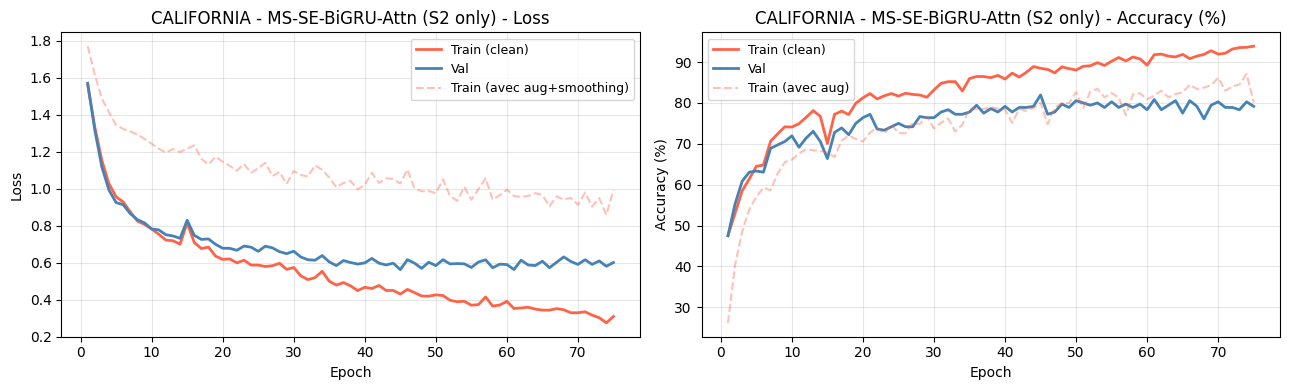

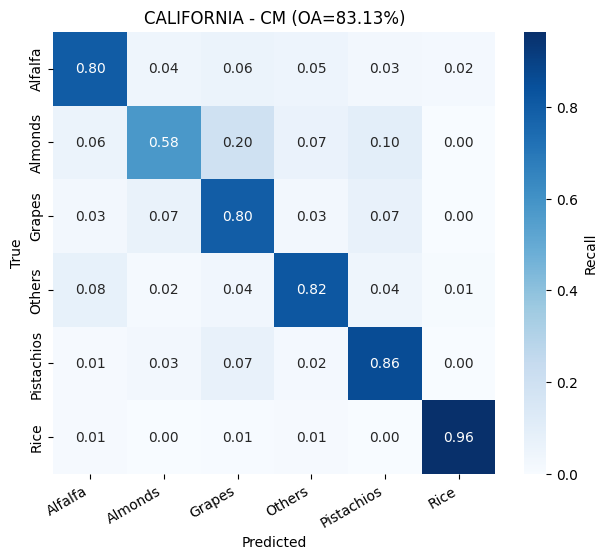


- CLASSIFICATION REPORT California -
              precision    recall  f1-score   support

     Alfalfa      0.604     0.800     0.688       674
     Almonds      0.567     0.580     0.573       483
      Grapes      0.831     0.796     0.813      1754
      Others      0.948     0.820     0.880      3212
  Pistachios      0.467     0.862     0.605       340
        Rice      0.970     0.964     0.967      1737

    accuracy                          0.831      8200
   macro avg      0.731     0.804     0.754      8200
weighted avg      0.857     0.831     0.839      8200



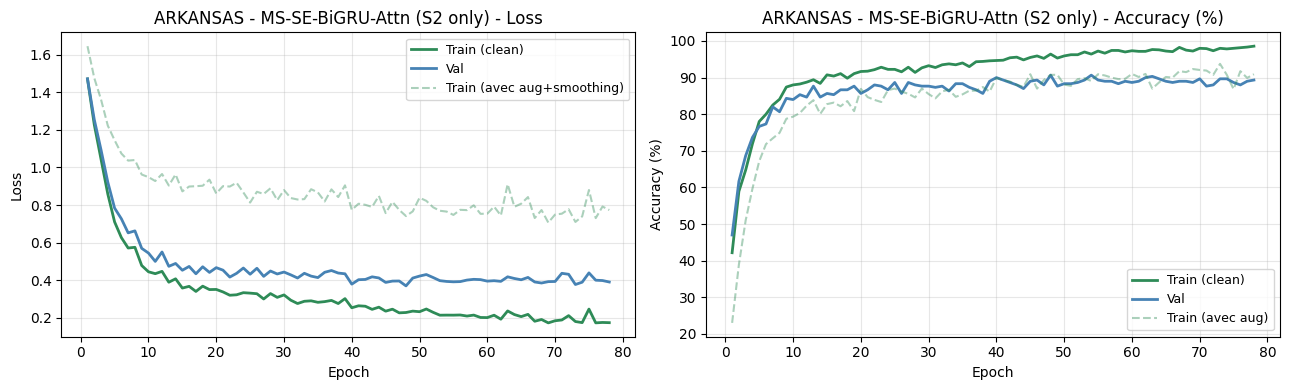

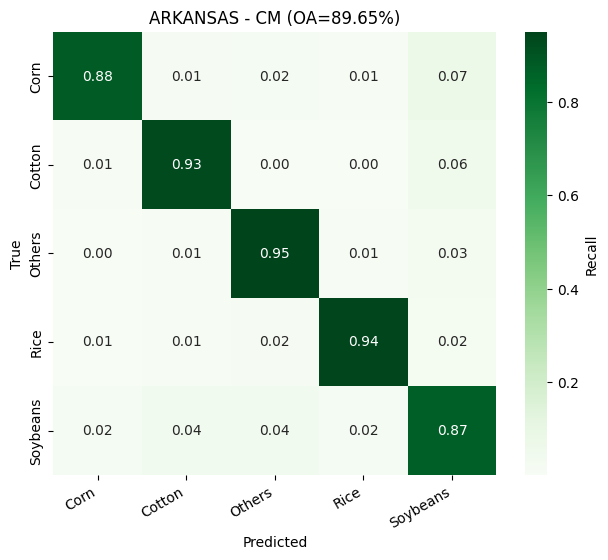


- CLASSIFICATION REPORT Arkansas -
              precision    recall  f1-score   support

        Corn      0.910     0.881     0.895      1222
      Cotton      0.664     0.931     0.775       462
      Others      0.534     0.949     0.683       316
        Rice      0.946     0.943     0.945      2123
    Soybeans      0.955     0.870     0.911      4377

    accuracy                          0.896      8500
   macro avg      0.802     0.915     0.842      8500
weighted avg      0.915     0.896     0.901      8500



In [14]:
def plot_history(hist, label, color='tomato'):
    """Trace les courbes propres : clean train (mode eval, sans aug) vs val.
       Loss/Acc avec aug+smoothing/MixUp en pointille pour info."""
    eps = range(1, len(hist['loss']) + 1)
    fig, ax = plt.subplots(1, 2, figsize=(13, 4))

    # LOSS
    ax[0].plot(eps, hist['clean_loss'], color=color, label='Train (clean)', linewidth=2)
    ax[0].plot(eps, hist['val_loss'],   color='steelblue', label='Val', linewidth=2)
    ax[0].plot(eps, hist['loss'], color=color, linestyle='--', alpha=0.4,
               label='Train (avec aug+smoothing)')
    ax[0].set_title(f'{label} - Loss')
    ax[0].set_xlabel('Epoch'); ax[0].set_ylabel('Loss')
    ax[0].legend(fontsize=9); ax[0].grid(alpha=0.3)

    # ACCURACY
    ax[1].plot(eps, hist['clean_acc'], color=color, label='Train (clean)', linewidth=2)
    ax[1].plot(eps, hist['val_acc'],   color='steelblue', label='Val', linewidth=2)
    ax[1].plot(eps, hist['acc'], color=color, linestyle='--', alpha=0.4,
               label='Train (avec aug)')
    ax[1].set_title(f'{label} - Accuracy (%)')
    ax[1].set_xlabel('Epoch'); ax[1].set_ylabel('Accuracy (%)')
    ax[1].legend(fontsize=9); ax[1].grid(alpha=0.3)
    plt.tight_layout(); plt.show()


def plot_cm(y_true, y_pred, classes, title, cmap='Blues'):
    cm = confusion_matrix(y_true, y_pred, normalize='true')
    fig, ax = plt.subplots(figsize=(6.5, 5.5))
    sns.heatmap(cm, annot=True, fmt='.2f', cmap=cmap, xticklabels=classes,
                yticklabels=classes, square=True, cbar_kws={'label':'Recall'}, ax=ax)
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    ax.set_title(title); plt.xticks(rotation=30, ha='right'); plt.tight_layout(); plt.show()


# California
plot_history(hist_CA_p1, 'CALIFORNIA - MS-SE-BiGRU-Attn (S2 only)')
plot_cm(res_CA_p1['y_true'], res_CA_p1['pred'], list(data_CA_p1['le'].classes_),
        title=f'CALIFORNIA - CM (OA={res_CA_p1["OA"]:.2f}%)')
print('\n- CLASSIFICATION REPORT California -')
print(classification_report(res_CA_p1['y_true'], res_CA_p1['pred'],
                            target_names=list(data_CA_p1['le'].classes_), digits=3))

# Arkansas
plot_history(hist_AR_p1, 'ARKANSAS - MS-SE-BiGRU-Attn (S2 only)', color='seagreen')
plot_cm(res_AR_p1['y_true'], res_AR_p1['pred'], list(data_AR_p1['le'].classes_),
        title=f'ARKANSAS - CM (OA={res_AR_p1["OA"]:.2f}%)', cmap='Greens')
print('\n- CLASSIFICATION REPORT Arkansas -')
print(classification_report(res_AR_p1['y_true'], res_AR_p1['pred'],
                            target_names=list(data_AR_p1['le'].classes_), digits=3))


### Comparaison detaillee : Section A (NEW) vs Partie 1 enrichi (MCTNet)

> Valeurs Partie 1 hardcodees ci-dessous. Si tu refais Partie 1, mets-les a jour.

#### Pourquoi 4 graphes ?

1. **Bar chart 3 metriques** (OA / Kappa / F1) : vue synthetique cote a cote
2. **F1 par classe** : revele si certaines classes profitent plus (Almonds, Pistachios sont les plus difficiles)
3. **Delta vs Partie 1** : gain absolu en points - permet de voir si l'amelioration est uniforme ou ciblee
4. **Tableau recap** : exporte en CSV pour le rapport

#### Interpretation attendue

Si tes valeurs **NEW** depassent **P1** sur OA -> ton archi domine MCTNet sur S2 seul.
Si gap > 3 points -> amelioration architecturale significative.
Si gap < 1 point -> equivalent (acceptable, on n'a pas degrade).

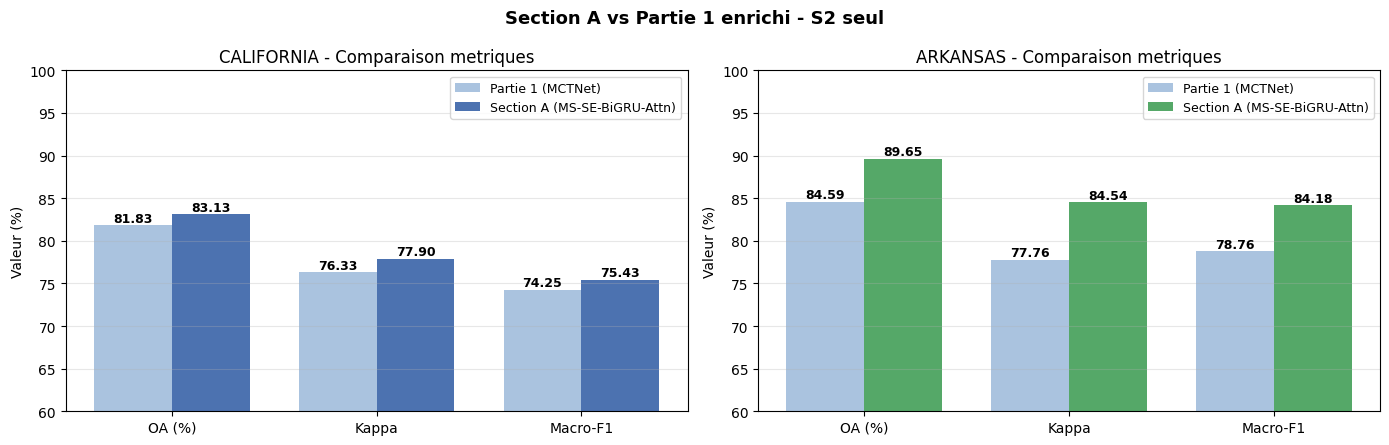

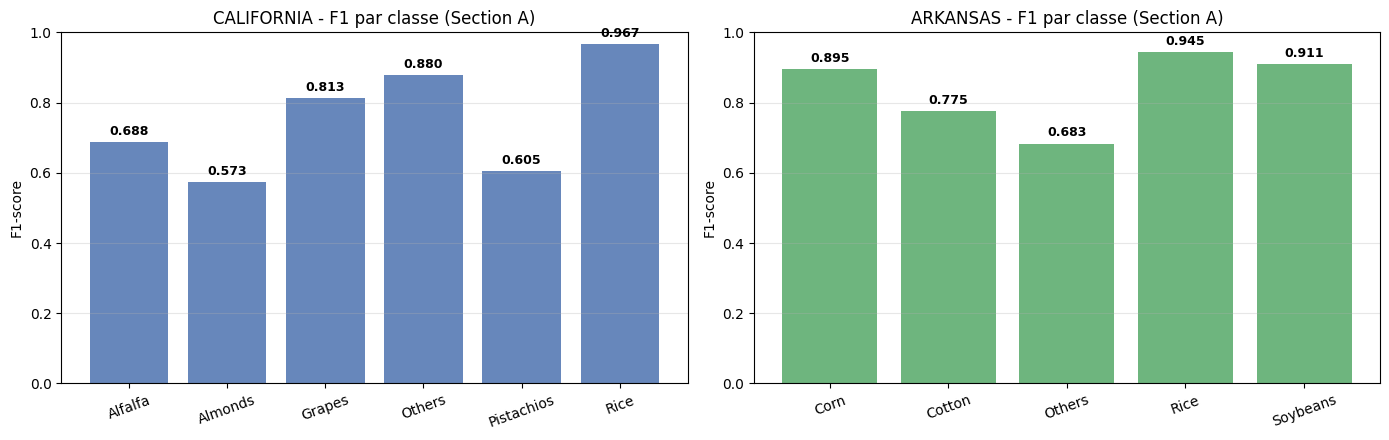

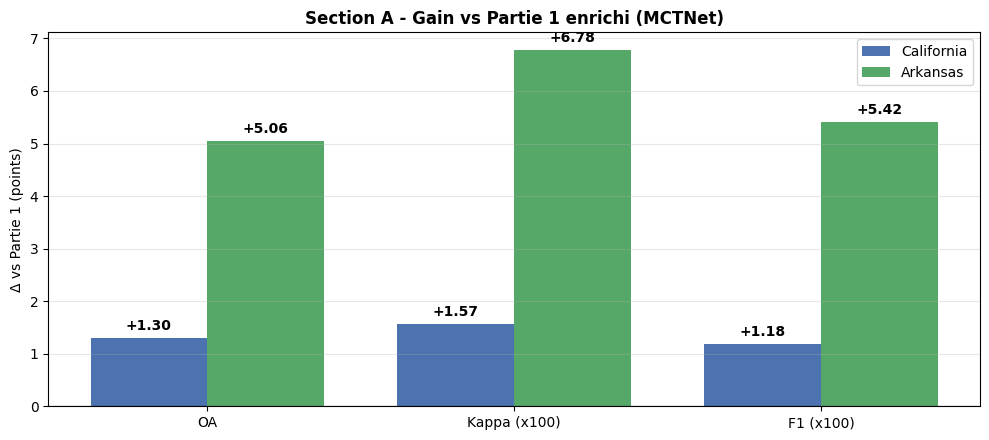


=== Tableau Section A vs Partie 1 enrichi ===
      Zone                       Modele    OA  Kappa     F1
CALIFORNIA            Partie 1 - MCTNet 81.83 0.7633 0.7425
CALIFORNIA Section A - MS-SE-BiGRU-Attn 83.13 0.7790 0.7543
  ARKANSAS            Partie 1 - MCTNet 84.59 0.7776 0.7876
  ARKANSAS Section A - MS-SE-BiGRU-Attn 89.65 0.8454 0.8418

✔ saved: data\processed/comparaison_sectionA_vs_partie1.csv


In [15]:
# === Valeurs hardcodees Partie 1 enrichi (MCTNet S2 only, split 240/60/reste)
P1_CA = {'OA': 81.83, 'Kappa': 0.7633, 'F1': 0.7425}
P1_AR = {'OA': 84.59, 'Kappa': 0.7776, 'F1': 0.7876}

NEW_CA = {'OA': res_CA_p1['OA'], 'Kappa': res_CA_p1['Kappa'], 'F1': res_CA_p1['F1']}
NEW_AR = {'OA': res_AR_p1['OA'], 'Kappa': res_AR_p1['Kappa'], 'F1': res_AR_p1['F1']}


# 1) Bar chart 3 metriques cote a cote
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
metrics = ['OA (%)', 'Kappa', 'Macro-F1']

for ax, (zone, p1, new, color) in zip(axes, [
    ('CALIFORNIA', P1_CA, NEW_CA, '#4C72B0'),
    ('ARKANSAS',   P1_AR, NEW_AR, '#55A868')
]):
    p1_vals  = [p1['OA'],  p1['Kappa']*100,  p1['F1']*100]
    new_vals = [new['OA'], new['Kappa']*100, new['F1']*100]
    x = np.arange(len(metrics)); w = 0.38
    b1 = ax.bar(x - w/2, p1_vals,  w, label='Partie 1 (MCTNet)',         color='#aac3df')
    b2 = ax.bar(x + w/2, new_vals, w, label='Section A (MS-SE-BiGRU-Attn)', color=color)
    ax.set_xticks(x); ax.set_xticklabels(metrics)
    ax.set_ylabel('Valeur (%)'); ax.set_title(f'{zone} - Comparaison metriques')
    ax.set_ylim([60, 100]); ax.grid(axis='y', alpha=0.3); ax.legend(fontsize=9)
    for b, v in list(zip(b1, p1_vals)) + list(zip(b2, new_vals)):
        ax.text(b.get_x() + b.get_width()/2, v + 0.4, f'{v:.2f}',
                ha='center', fontsize=9, fontweight='bold')
plt.suptitle('Section A vs Partie 1 enrichi - S2 seul', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()


# 2) Per-class F1 comparison (necessite la confusion par classe)
def per_class_f1(y_true, y_pred, classes):
    f1s = []
    for cls_idx, cls_name in enumerate(classes):
        yt = (y_true == cls_idx).astype(int)
        yp = (y_pred == cls_idx).astype(int)
        f1s.append(f1_score(yt, yp, zero_division=0))
    return f1s

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
for ax, (zone, data, res, le, color) in zip(axes, [
    ('CALIFORNIA', data_CA_p1, res_CA_p1, data_CA_p1['le'], '#4C72B0'),
    ('ARKANSAS',   data_AR_p1, res_AR_p1, data_AR_p1['le'], '#55A868')
]):
    classes = list(le.classes_)
    f1_new = per_class_f1(res['y_true'], res['pred'], classes)
    x = np.arange(len(classes))
    bars = ax.bar(x, f1_new, color=color, alpha=0.85)
    ax.set_xticks(x); ax.set_xticklabels(classes, rotation=20)
    ax.set_ylabel('F1-score'); ax.set_title(f'{zone} - F1 par classe (Section A)')
    ax.set_ylim([0, 1]); ax.grid(axis='y', alpha=0.3)
    for b, v in zip(bars, f1_new):
        ax.text(b.get_x() + b.get_width()/2, v + 0.02, f'{v:.3f}',
                ha='center', fontsize=9, fontweight='bold')
plt.tight_layout(); plt.show()


# 3) Delta OA / Kappa / F1 (gain absolu)
delta_CA = {
    'OA':    NEW_CA['OA'] - P1_CA['OA'],
    'Kappa': (NEW_CA['Kappa'] - P1_CA['Kappa']) * 100,
    'F1':    (NEW_CA['F1'] - P1_CA['F1']) * 100,
}
delta_AR = {
    'OA':    NEW_AR['OA'] - P1_AR['OA'],
    'Kappa': (NEW_AR['Kappa'] - P1_AR['Kappa']) * 100,
    'F1':    (NEW_AR['F1'] - P1_AR['F1']) * 100,
}

fig, ax = plt.subplots(figsize=(10, 4.5))
metrics_ = ['OA', 'Kappa (x100)', 'F1 (x100)']
ca_vals = [delta_CA['OA'], delta_CA['Kappa'], delta_CA['F1']]
ar_vals = [delta_AR['OA'], delta_AR['Kappa'], delta_AR['F1']]
x = np.arange(len(metrics_)); w = 0.38
b1 = ax.bar(x - w/2, ca_vals, w, label='California', color='#4C72B0')
b2 = ax.bar(x + w/2, ar_vals, w, label='Arkansas',   color='#55A868')
ax.axhline(0, color='black', lw=0.8)
ax.set_xticks(x); ax.set_xticklabels(metrics_)
ax.set_ylabel('Δ vs Partie 1 (points)')
ax.set_title('Section A - Gain vs Partie 1 enrichi (MCTNet)', fontweight='bold')
ax.grid(axis='y', alpha=0.3); ax.legend()
for b, v in list(zip(b1, ca_vals)) + list(zip(b2, ar_vals)):
    off = 0.15 if v >= 0 else -0.5
    ax.text(b.get_x() + b.get_width()/2, v + off, f'{v:+.2f}',
            ha='center', fontsize=10, fontweight='bold')
plt.tight_layout(); plt.show()


# 4) Tableau recap clair
df_cmp = pd.DataFrame([
    {'Zone':'CALIFORNIA','Modele':'Partie 1 - MCTNet',          'OA':P1_CA['OA'],    'Kappa':P1_CA['Kappa'],    'F1':P1_CA['F1']},
    {'Zone':'CALIFORNIA','Modele':'Section A - MS-SE-BiGRU-Attn','OA':NEW_CA['OA'],   'Kappa':NEW_CA['Kappa'],   'F1':NEW_CA['F1']},
    {'Zone':'ARKANSAS',  'Modele':'Partie 1 - MCTNet',          'OA':P1_AR['OA'],    'Kappa':P1_AR['Kappa'],    'F1':P1_AR['F1']},
    {'Zone':'ARKANSAS',  'Modele':'Section A - MS-SE-BiGRU-Attn','OA':NEW_AR['OA'],   'Kappa':NEW_AR['Kappa'],   'F1':NEW_AR['F1']},
])
df_cmp['OA']    = df_cmp['OA'].round(2)
df_cmp['Kappa'] = df_cmp['Kappa'].round(4)
df_cmp['F1']    = df_cmp['F1'].round(4)
print('\n=== Tableau Section A vs Partie 1 enrichi ===')
print(df_cmp.to_string(index=False))
df_cmp.to_csv(PROCESSED_DIR / 'comparaison_sectionA_vs_partie1.csv', index=False)
print(f'\n✔ saved: {PROCESSED_DIR}/comparaison_sectionA_vs_partie1.csv')


---
# Section B - Ablation covariables (memes CSV que Partie 2 modifiee)

## Objectif

Tester notre architecture **MS-SE-BiGRU-Attn** sur les **5 configurations** de l'ablation :
- `S2_only`    : 10 bandes Sentinel-2
- `S2_climate` : 10 + 3 (temperature, precipitations, dewpoint)
- `S2_soil`    : 10 + 3 (pH, carbone organique, texture)
- `S2_topo`    : 10 + 2 (elevation, landforms)
- `S2_all`     : 10 + 8 covariables

## Strategie : regularisation **per-config**

Pourquoi ne pas utiliser les memes hyperparams pour tous ?
- `S2_only` (10 bandes) : moins de risque overfit -> dropout standard, MixUp ON
- `S2_climate/soil/topo` (12-13 bandes) : un peu plus de bandes -> regul moderee, MixUp OFF
- `S2_all` (18 bandes) : 80% de bandes en plus -> regul renforcee + capacite augmentee + train plus long

Defini dans `CONFIG_REG` (cellule 4).

## Pourquoi MixUp desactive sur les configs covariables ?

MixUp combine 2 samples : `X_mix = 0.7*X_a + 0.3*X_b`. Quand le sample contient des covariables **statiques** (pH=5.6, elevation=350m), le melange cree des combinaisons **physiquement impossibles** -> bruit nefaste.

Pour S2 spectral pur, c'est OK car les valeurs spectrales sont continues et le melange reste plausible.

## Pourquoi `hidden` scale avec `n_bands` ?

Mon modele de base a `hidden=64` fixe. Pour S2_all (18 bandes), le multi-scale conv compresse 18 -> 64 -> bottleneck.

MCTNet (P2) scale `d_model = n_bands_total` -> sa capacite augmente avec les inputs (130K params pour S2_all). On fait pareil :
- `S2_only` (10 bandes) -> hidden=64 (~50K params)
- `S2_all` (18 bandes) -> hidden=144 (~120K params, override) -> capacite ~ MCTNet

## Pourquoi class weights inverse-frequence ?

Les classes sont desequilibrees (Alfalfa rare en CA, Others dominant en AR). Sans poids :
- Le modele apprend surtout les classes frequentes
- Les classes rares ont F1 faible
- L'OA reste bonne mais Macro-F1 souffre

Avec poids = `1 / freq_classe`, le modele est force de bien classer les minorites.

In [27]:
def build_section_b_datasets(csv_path, label, label_map=None):
    """Construit les 5 datasets pour notre archi avec covariables par pixel.
       Lit le split existant du CSV (identique Partie 1 et Partie 2)."""
    df = pd.read_csv(csv_path)

    # Harmonise label
    if 'label' in df.columns and 'crop_label' not in df.columns:
        df = df.rename(columns={'label': 'crop_label'})
    if label_map is not None:
        df['crop_label'] = df['crop_label'].map(lambda v: label_map.get(int(v), 'Others')
                                                if not isinstance(v, str) else v).fillna('Others')

    COV_CLIMATE = ['temp_mean_c', 'precip_mm', 'dewpoint_c']
    COV_SOIL    = ['soil_ph', 'soil_oc', 'soil_texture']
    COV_TOPO    = ['elevation_m', 'landform_class']
    META        = ['crop_label', 'split'] + COV_CLIMATE + COV_SOIL + COV_TOPO

    s2_cols = [c for c in df.columns if c not in META]
    assert len(s2_cols) == N_BANDS_S2 * N_DATES, \
        f'[{label}] attendu {N_BANDS_S2*N_DATES} S2, got {len(s2_cols)}'

    # Reordonne les bandes vers ALL_BANDS (paper order)
    def sort_key(c):
        b, t = c.rsplit('_t', 1)
        return (BAND_ORDER_WIDE.index(b), int(t))
    s2_cols = sorted(s2_cols, key=sort_key)

    band_map = {'B02':'B2','B03':'B3','B04':'B4','B05':'B5','B06':'B6',
                'B07':'B7','B08':'B8','B8A':'B8A','B11':'B11','B12':'B12'}
    perm = []
    for paper_band in ALL_BANDS:
        bi = BAND_ORDER_WIDE.index(band_map[paper_band])
        for t in range(N_DATES):
            perm.append(bi * N_DATES + t)

    X_raw = df[s2_cols].values.astype('float32')
    X_s2  = X_raw[:, perm]
    N     = X_s2.shape[0]
    X_s2_3d = X_s2.reshape(N, N_BANDS_S2, N_DATES).transpose(0, 2, 1)   # (N, 36, 10)
    mask    = (np.abs(X_s2_3d).sum(axis=-1) > 0).astype('float32')

    # Split
    tr = (df['split'].values == 'train')
    va = (df['split'].values == 'val')
    te = (df['split'].values == 'test')
    print(f'  [{label}] train={tr.sum()} val={va.sum()} test={te.sum()}')

    # Encoder labels
    le = LabelEncoder()
    y  = le.fit_transform(df['crop_label']).astype('int64')

    # Standardize S2 fit train
    Xf = X_s2_3d.reshape(N, -1)
    sc = StandardScaler()
    Xs = Xf.copy()
    Xs[tr]  = sc.fit_transform(Xf[tr])
    Xs[~tr] = sc.transform(Xf[~tr])
    Xs[Xf == 0] = 0.0
    X_s2_3d = Xs.reshape(N, N_DATES, N_BANDS_S2)

    # Cov pixels normalises (fit train)
    def norm_cov(cols):
        if not all(c in df.columns for c in cols):
            return None
        a = df[cols].values.astype('float32')
        sc2 = StandardScaler()
        a_out = a.copy()
        a_out[tr]  = sc2.fit_transform(a[tr])
        a_out[~tr] = sc2.transform(a[~tr])
        return a_out

    clim = norm_cov(COV_CLIMATE)
    soil = norm_cov(COV_SOIL)
    topo = norm_cov(COV_TOPO)
    all_ = np.concatenate([x for x in [clim, soil, topo] if x is not None], axis=1)

    def add_cov(X_3d, cov_2d):
        """(N,36,10) + (N,k) -> (N,36,10+k) en repetant cov sur dates."""
        N_, T, B = X_3d.shape
        cov_3d = np.tile(cov_2d[:, np.newaxis, :], (1, T, 1)).astype('float32')
        return np.concatenate([X_3d, cov_3d], axis=2)

    cov_dict = {
        'S2_only':    None,
        'S2_climate': clim,
        'S2_soil':    soil,
        'S2_topo':    topo,
        'S2_all':     all_,
    }

    datasets = {}
    for cfg, cov_px in cov_dict.items():
        X_full = X_s2_3d if cov_px is None else add_cov(X_s2_3d, cov_px)
        datasets[cfg] = {
            'n_bands': X_full.shape[2],
            'X_train': X_full[tr], 'm_train': mask[tr], 'y_train': y[tr],
            'X_val'  : X_full[va], 'm_val'  : mask[va], 'y_val'  : y[va],
            'X_test' : X_full[te], 'm_test' : mask[te], 'y_test' : y[te],
            'classes': list(le.classes_),
        }
    return datasets, le


print('=== Construction datasets Section B ===')
print('-- CALIFORNIA --')
datasets_CA_b, le_CA_b = build_section_b_datasets(
    PROCESSED_DIR / 'CALIFORNIA_FULL_split.csv', 'CA', label_map=LABEL_MAP_CA)
print('-- ARKANSAS --')
datasets_AR_b, le_AR_b = build_section_b_datasets(
    PROCESSED_DIR / 'ARKANSAS_FULL_split.csv', 'AR', label_map=LABEL_MAP_AR)


=== Construction datasets Section B ===
-- CALIFORNIA --
  [CA] train=1440 val=360 test=8200
-- ARKANSAS --
  [AR] train=1200 val=300 test=8500


In [28]:
# CALIFORNIA - Ablation 5 configs avec MS-SE-BiGRU-Attn
# - hidden scale avec n_bands (override possible via CONFIG_REG)
# - class weights inverse freq
# - epochs/patience per-config (boost pour S2_all)
results_CA_b   = {}
histories_CA_b = {}
cw_CA = compute_class_weights(datasets_CA_b['S2_only']['y_train'],
                               len(datasets_CA_b['S2_only']['classes']), DEVICE)
for cfg in CONFIGS_P2:
    reg = CONFIG_REG[cfg]
    h_default = hidden_for_n_bands(datasets_CA_b[cfg]['n_bands'])
    h = reg.get('hidden_override') or h_default
    eps = reg.get('epochs', 200)
    pat = reg.get('patience', 30)
    print(f'\n-- CALIFORNIA - {cfg} (hidden={h}, dropout={reg["dropout"]}, lr={reg["lr"]}, '
          f'mixup={reg["use_mixup"]}, epochs={eps}, patience={pat}) --')
    d = datasets_CA_b[cfg]
    tr_loader = make_loader(d['X_train'], d['y_train'], mask=d['m_train'], shuffle=True)
    va_loader = make_loader(d['X_val'],   d['y_val'],   mask=d['m_val'])

    model = build_model(
        n_bands=d['n_bands'], num_classes=len(d['classes']),
        device=DEVICE, hidden=h, dropout=reg['dropout'],
    )
    model, hist = train_model(
        model, tr_loader, va_loader, DEVICE,
        label=f'CA-{cfg}', use_mixup=reg['use_mixup'], use_mask=True,
        label_smoothing=reg['label_smoothing'], lr=reg['lr'],
        class_weights=cw_CA, epochs=eps, patience=pat,
    )
    res = evaluate_model(model, d['X_test'], d['y_test'], DEVICE, mask_test=d['m_test'])
    results_CA_b[cfg]   = res
    histories_CA_b[cfg] = hist
    print(f'  -> OA={res["OA"]:.2f}%  Kappa={res["Kappa"]:.4f}  Macro-F1={res["F1"]:.4f}')



-- CALIFORNIA - S2_only (hidden=64, dropout=0.35, lr=0.001, mixup=True, epochs=200, patience=30) --
  MS-SE-BiGRU-Attn BALANCED | bands=10  classes=6  params=56,919  hidden=64  dropout=0.35

  [CA-S2_only] training... (epochs=200, lr=0.001, wd=0.001, cw=True)
    [  1/200] aug-loss=1.774 aug-acc=27.2%  | CLEAN-loss=1.563 CLEAN-acc=46.4%  | val=1.578 acc=41.1%  wait=0/30
    [ 25/200] aug-loss=1.105 aug-acc=74.1%  | CLEAN-loss=0.591 CLEAN-acc=81.1%  | val=0.664 acc=77.5%  wait=7/30
    [ 50/200] aug-loss=0.977 aug-acc=81.9%  | CLEAN-loss=0.417 CLEAN-acc=89.2%  | val=0.570 acc=80.8%  wait=11/30
    [ 75/200] aug-loss=0.986 aug-acc=81.7%  | CLEAN-loss=0.314 CLEAN-acc=92.9%  | val=0.560 acc=82.8%  wait=22/30
    early-stop ep=83  best=84.17% @ep53
    OK best val_acc=84.17% @ep53
  -> OA=81.33%  Kappa=0.7562  Macro-F1=0.7317

-- CALIFORNIA - S2_climate (hidden=84, dropout=0.4, lr=0.0007, mixup=False, epochs=200, patience=30) --
  MS-SE-BiGRU-Attn BALANCED | bands=13  classes=6  params=97,

In [21]:
# ARKANSAS - Ablation 5 configs avec MS-SE-BiGRU-Attn
results_AR_b   = {}
histories_AR_b = {}
cw_AR = compute_class_weights(datasets_AR_b['S2_only']['y_train'],
                               len(datasets_AR_b['S2_only']['classes']), DEVICE)
for cfg in CONFIGS_P2:
    reg = CONFIG_REG[cfg]
    h_default = hidden_for_n_bands(datasets_AR_b[cfg]['n_bands'])
    h = reg.get('hidden_override') or h_default
    eps = reg.get('epochs', 200)
    pat = reg.get('patience', 30)
    print(f'\n-- ARKANSAS - {cfg} (hidden={h}, dropout={reg["dropout"]}, lr={reg["lr"]}, '
          f'mixup={reg["use_mixup"]}, epochs={eps}, patience={pat}) --')
    d = datasets_AR_b[cfg]
    tr_loader = make_loader(d['X_train'], d['y_train'], mask=d['m_train'], shuffle=True)
    va_loader = make_loader(d['X_val'],   d['y_val'],   mask=d['m_val'])

    model = build_model(
        n_bands=d['n_bands'], num_classes=len(d['classes']),
        device=DEVICE, hidden=h, dropout=reg['dropout'],
    )
    model, hist = train_model(
        model, tr_loader, va_loader, DEVICE,
        label=f'AR-{cfg}', use_mixup=reg['use_mixup'], use_mask=True,
        label_smoothing=reg['label_smoothing'], lr=reg['lr'],
        class_weights=cw_AR, epochs=eps, patience=pat,
    )
    res = evaluate_model(model, d['X_test'], d['y_test'], DEVICE, mask_test=d['m_test'])
    results_AR_b[cfg]   = res
    histories_AR_b[cfg] = hist
    print(f'  -> OA={res["OA"]:.2f}%  Kappa={res["Kappa"]:.4f}  Macro-F1={res["F1"]:.4f}')



-- ARKANSAS - S2_only (hidden=64, dropout=0.35, lr=0.001, mixup=True) --
  MS-SE-BiGRU-Attn BALANCED | bands=10  classes=5  params=56,854  hidden=64  dropout=0.35

  [AR-S2_only] training... (epochs=200, lr=0.001, wd=0.001, cw=True)
    [  1/200] aug-loss=1.604 aug-acc=26.3%  | CLEAN-loss=1.406 CLEAN-acc=54.7%  | val=1.454 acc=51.7%  wait=0/30
    [ 25/200] aug-loss=0.850 aug-acc=87.8%  | CLEAN-loss=0.321 CLEAN-acc=92.3%  | val=0.398 acc=90.3%  wait=8/30
    [ 50/200] aug-loss=0.807 aug-acc=86.3%  | CLEAN-loss=0.259 CLEAN-acc=94.3%  | val=0.373 acc=90.7%  wait=23/30
    early-stop ep=57  best=91.33% @ep27
    OK best val_acc=91.33% @ep27
  -> OA=86.49%  Kappa=0.8020  Macro-F1=0.8064

-- ARKANSAS - S2_climate (hidden=84, dropout=0.4, lr=0.0007, mixup=False) --
  MS-SE-BiGRU-Attn BALANCED | bands=13  classes=5  params=97,215  hidden=84  dropout=0.4

  [AR-S2_climate] training... (epochs=200, lr=0.0007, wd=0.001, cw=True)
    [  1/200] aug-loss=1.663 aug-acc=22.1%  | CLEAN-loss=1.494 CLE

### Visualisation Section B - Tableau ablation + meilleure config

=== ABLATION - MS-SE-BiGRU-Attn (Section B) ===
    Config CA OA (%) CA Kappa CA Macro-F1 AR OA (%) AR Kappa AR Macro-F1
   S2_only     81.33   0.7562      0.7317     86.49   0.8020      0.8064
S2_climate     81.73   0.7608      0.7369     84.60   0.7774      0.7891
   S2_soil     82.94   0.7753      0.7472     87.65   0.8174      0.8170
   S2_topo     79.98   0.7403      0.7189     87.25   0.8127      0.8125
    S2_all     81.45   0.7584      0.7336     87.39   0.8133      0.8178

saved: data\processed/ablation_results_NEW.csv


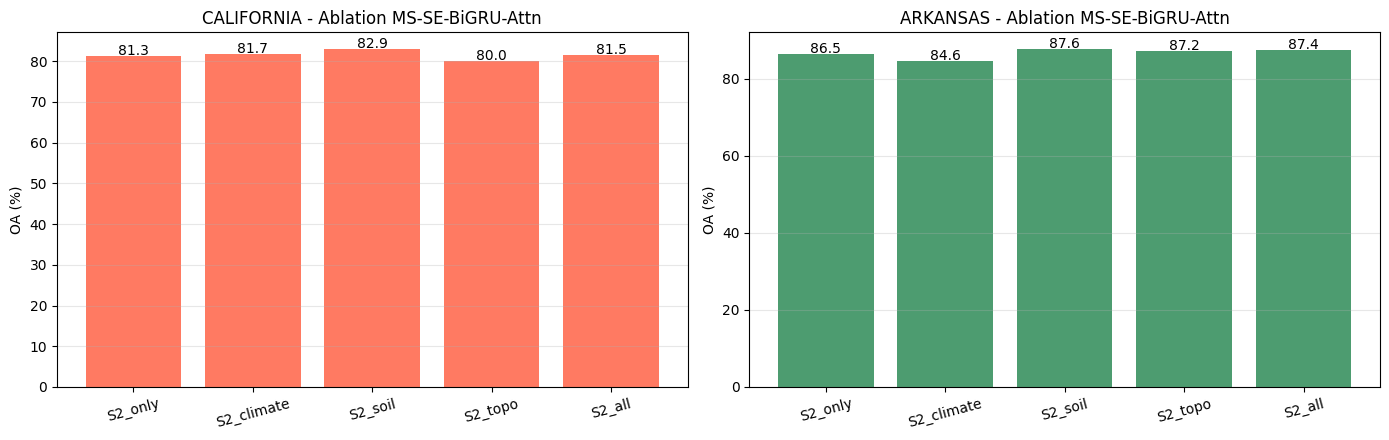


COURBES TRAINING - 5 configs CALIFORNIA


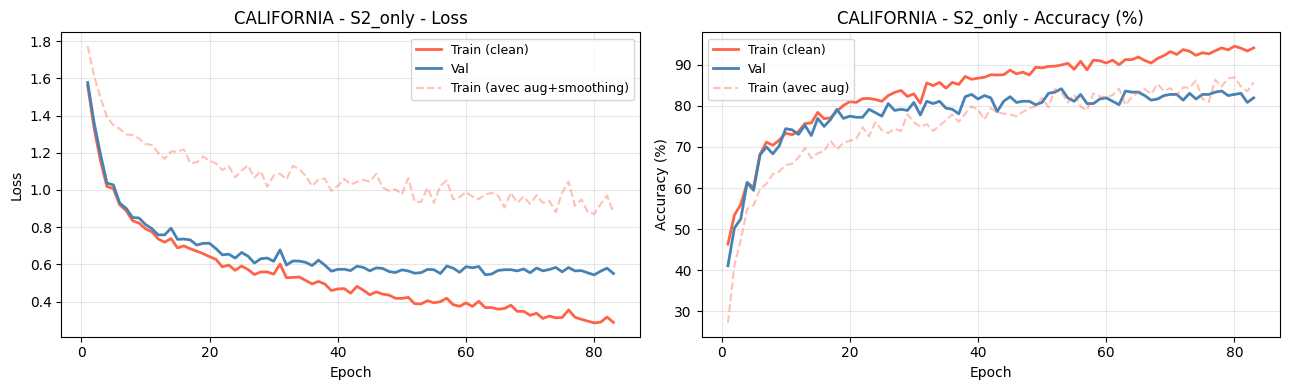

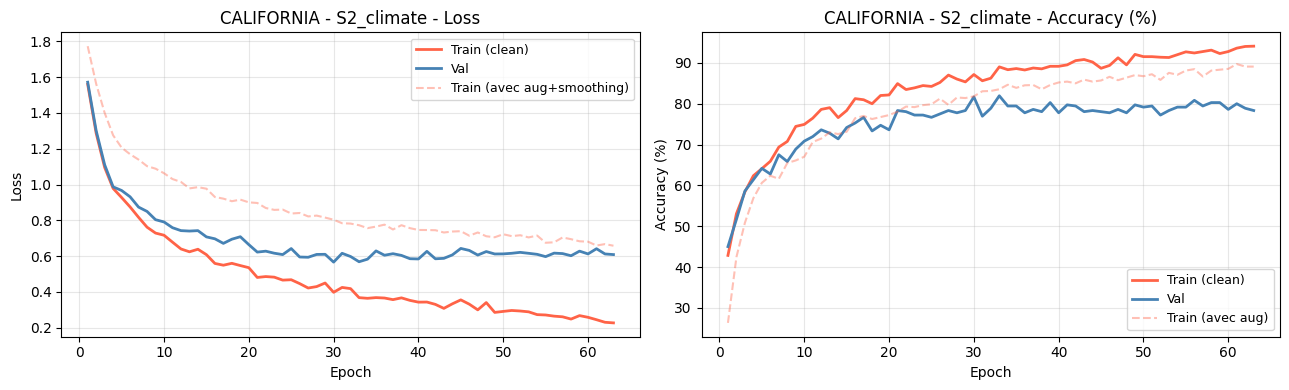

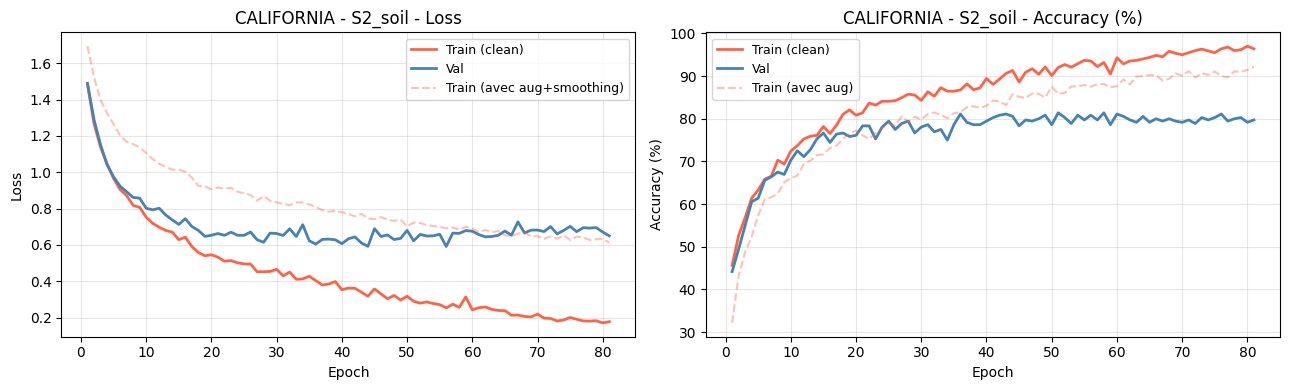

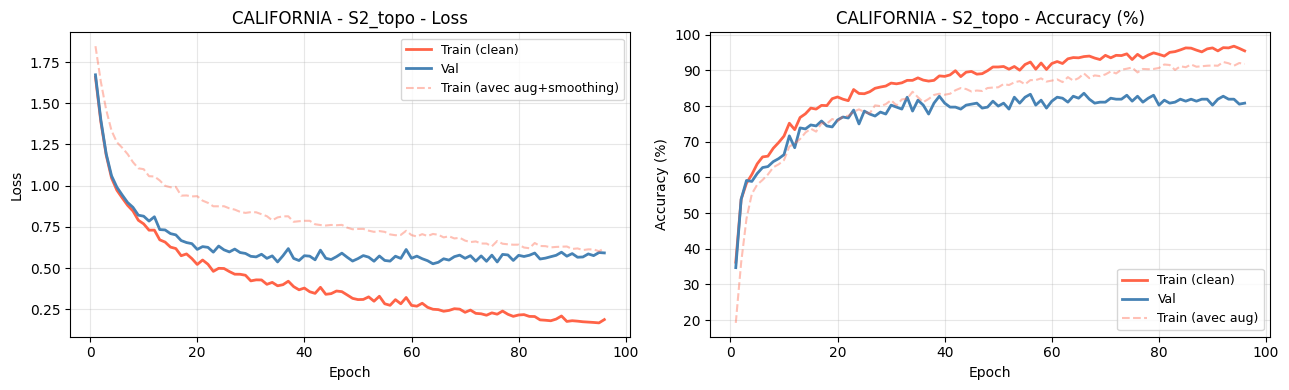

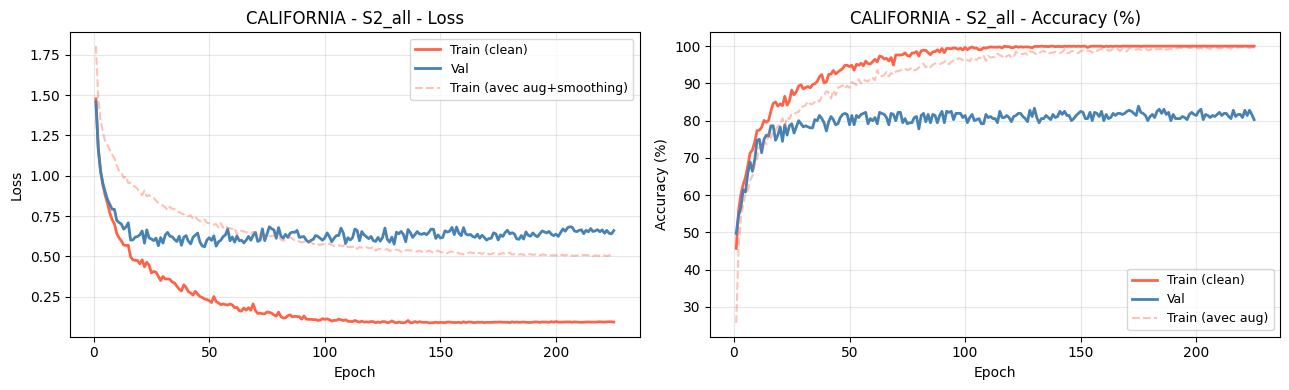


COURBES TRAINING - 5 configs ARKANSAS


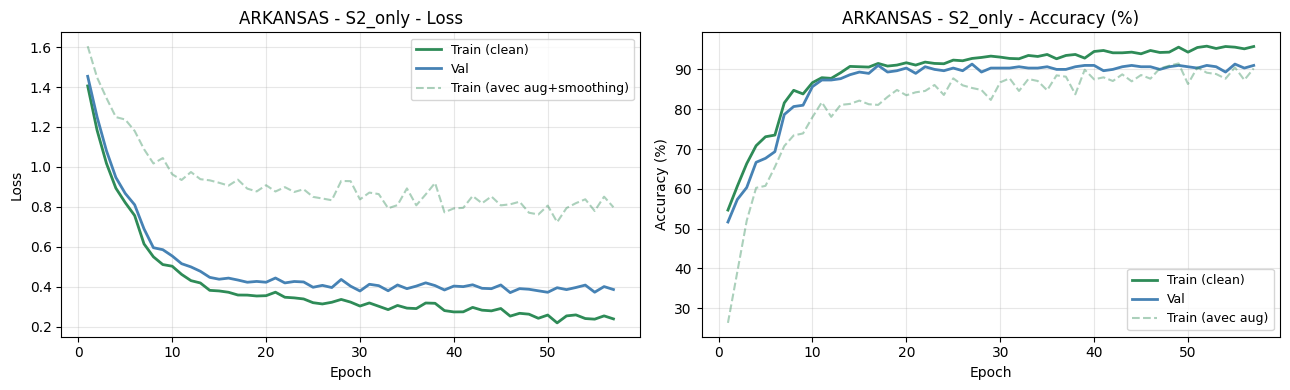

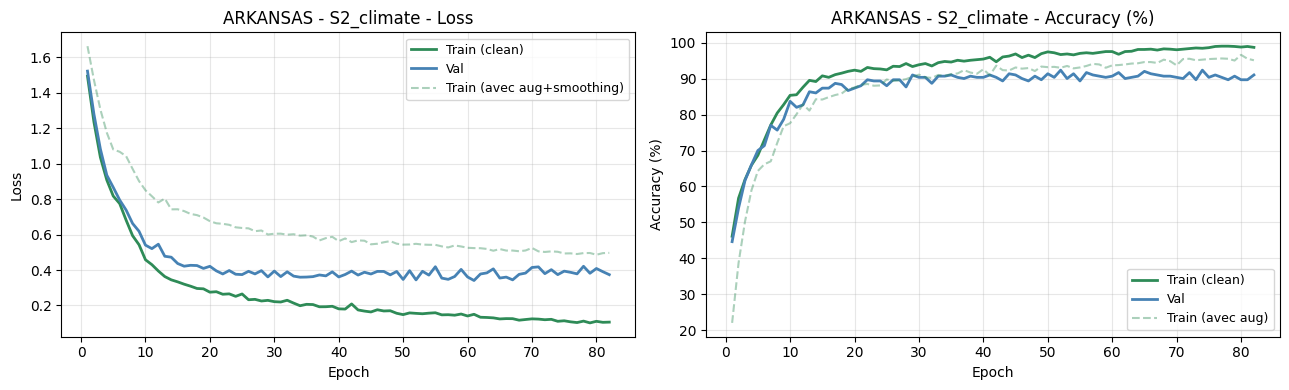

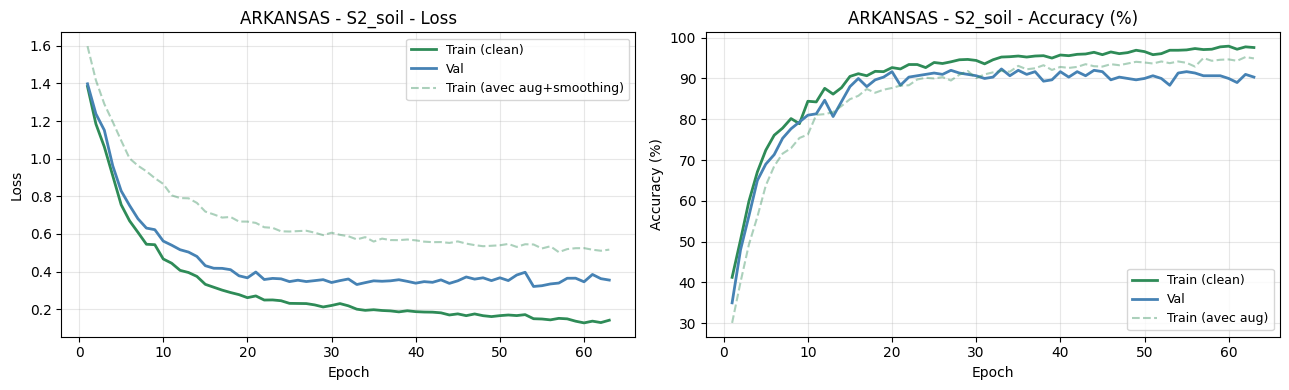

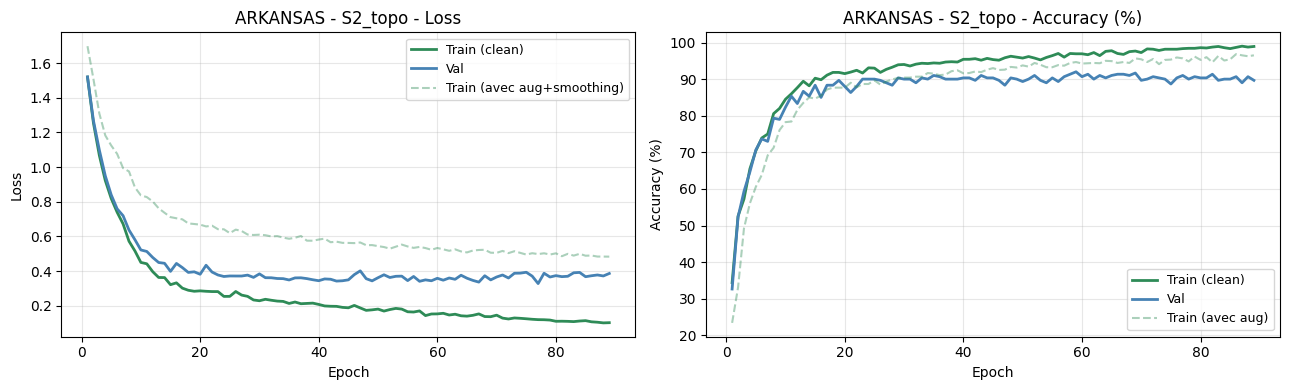

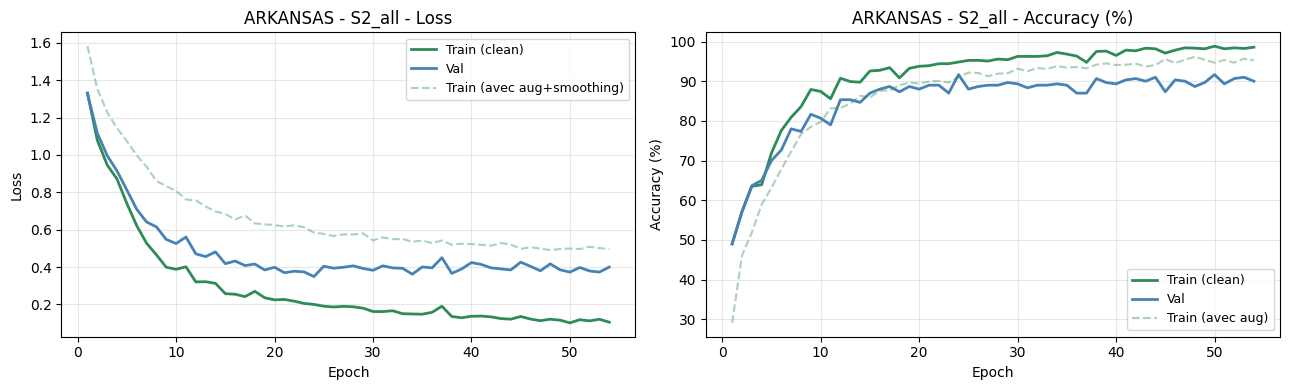

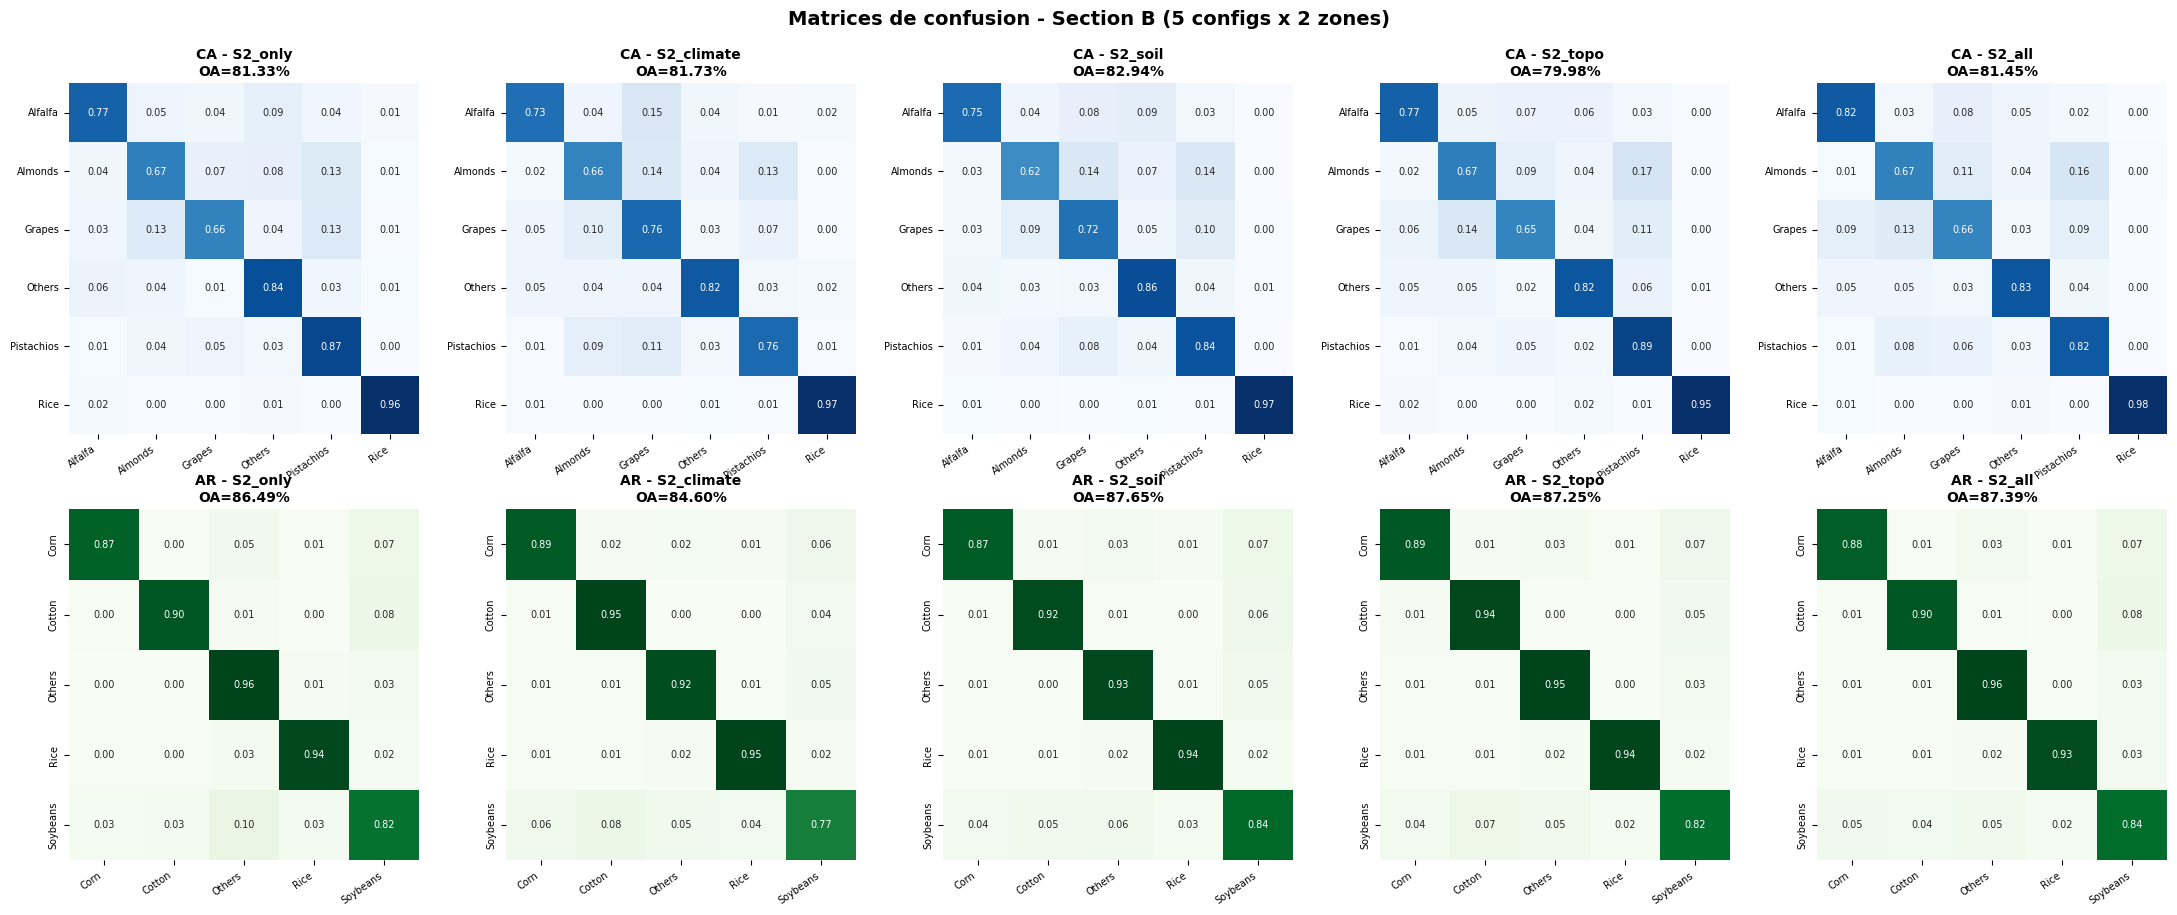


MATRICES DE CONFUSION DETAILLEES - S2_only vs S2_all


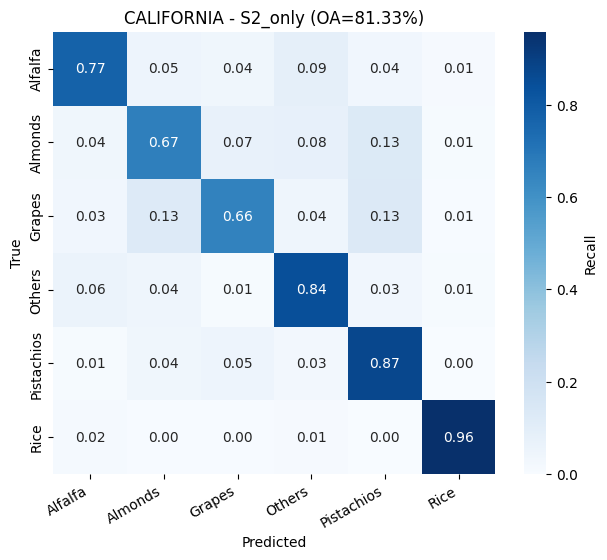

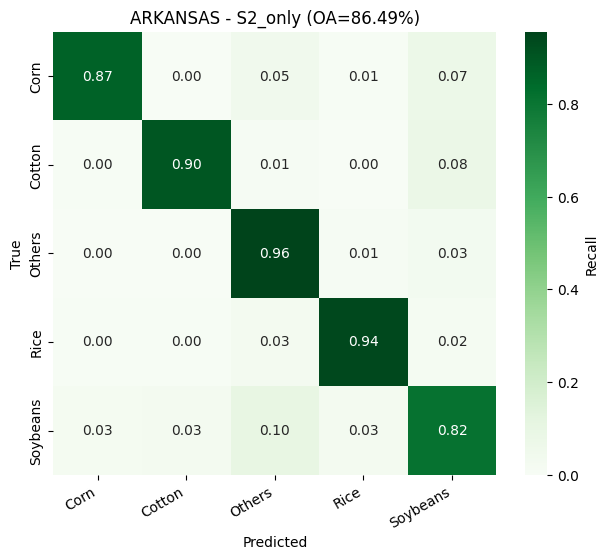

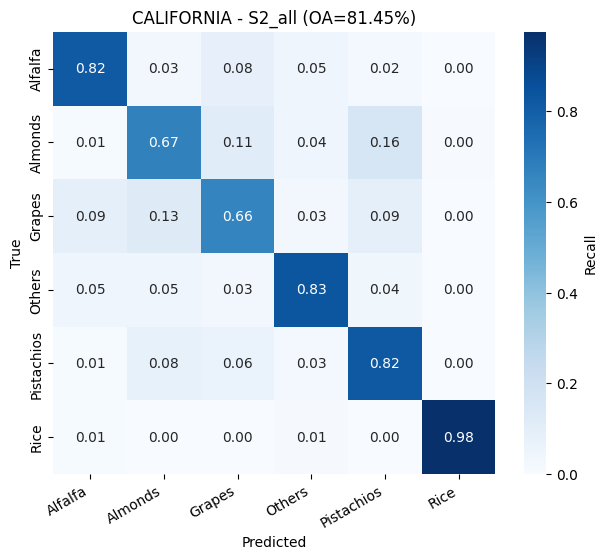

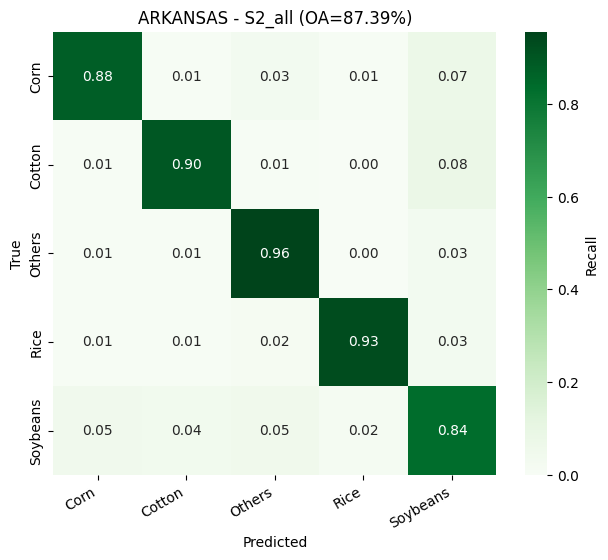


CLASSIFICATION REPORT - CALIFORNIA - S2_only
              precision    recall  f1-score   support

     Alfalfa      0.636     0.774     0.698       674
     Almonds      0.438     0.667     0.528       483
      Grapes      0.906     0.657     0.761      1754
      Others      0.929     0.844     0.885      3212
  Pistachios      0.407     0.874     0.555       340
        Rice      0.966     0.958     0.962      1737

    accuracy                          0.813      8200
   macro avg      0.714     0.796     0.732      8200
weighted avg      0.857     0.813     0.825      8200


CLASSIFICATION REPORT - ARKANSAS - S2_only
              precision    recall  f1-score   support

        Corn      0.898     0.867     0.882      1222
      Cotton      0.758     0.903     0.824       462
      Others      0.347     0.956     0.509       316
        Rice      0.933     0.942     0.937      2123
    Soybeans      0.952     0.816     0.879      4377

    accuracy                          0.8

In [29]:
# Tableau ablation NEW
rows = []
for cfg in CONFIGS_P2:
    ca = results_CA_b.get(cfg)
    ar = results_AR_b.get(cfg)
    rows.append({
        'Config'      : cfg,
        'CA OA (%)'   : f'{ca["OA"]:.2f}'    if ca else '--',
        'CA Kappa'    : f'{ca["Kappa"]:.4f}' if ca else '--',
        'CA Macro-F1' : f'{ca["F1"]:.4f}'    if ca else '--',
        'AR OA (%)'   : f'{ar["OA"]:.2f}'    if ar else '--',
        'AR Kappa'    : f'{ar["Kappa"]:.4f}' if ar else '--',
        'AR Macro-F1' : f'{ar["F1"]:.4f}'    if ar else '--',
    })
df_ablation_b = pd.DataFrame(rows)
print('=== ABLATION - MS-SE-BiGRU-Attn (Section B) ===')
print(df_ablation_b.to_string(index=False))
df_ablation_b.to_csv(PROCESSED_DIR / 'ablation_results_NEW.csv', index=False)
print(f'\nsaved: {PROCESSED_DIR}/ablation_results_NEW.csv')


# === Bar chart OA - 5 configs x 2 zones ======================================
fig, ax = plt.subplots(1, 2, figsize=(14, 4.5))
oa_CA = [results_CA_b[c]['OA'] for c in CONFIGS_P2]
oa_AR = [results_AR_b[c]['OA'] for c in CONFIGS_P2]
x = np.arange(len(CONFIGS_P2))

bars_CA = ax[0].bar(x, oa_CA, color='tomato', alpha=0.85)
ax[0].set_xticks(x); ax[0].set_xticklabels(CONFIGS_P2, rotation=15)
ax[0].set_ylabel('OA (%)'); ax[0].set_title('CALIFORNIA - Ablation MS-SE-BiGRU-Attn')
ax[0].grid(axis='y', alpha=0.3)
for b, v in zip(bars_CA, oa_CA):
    ax[0].text(b.get_x() + b.get_width()/2, v + 0.3, f'{v:.1f}', ha='center', fontsize=10)

bars_AR = ax[1].bar(x, oa_AR, color='seagreen', alpha=0.85)
ax[1].set_xticks(x); ax[1].set_xticklabels(CONFIGS_P2, rotation=15)
ax[1].set_ylabel('OA (%)'); ax[1].set_title('ARKANSAS - Ablation MS-SE-BiGRU-Attn')
ax[1].grid(axis='y', alpha=0.3)
for b, v in zip(bars_AR, oa_AR):
    ax[1].text(b.get_x() + b.get_width()/2, v + 0.3, f'{v:.1f}', ha='center', fontsize=10)
plt.tight_layout(); plt.show()


# === Courbes pour les 5 configs (CA + AR) ====================================
print('\n' + '=' * 60)
print('COURBES TRAINING - 5 configs CALIFORNIA')
print('=' * 60)
for cfg in CONFIGS_P2:
    plot_history(histories_CA_b[cfg], f'CALIFORNIA - {cfg}')

print('\n' + '=' * 60)
print('COURBES TRAINING - 5 configs ARKANSAS')
print('=' * 60)
for cfg in CONFIGS_P2:
    plot_history(histories_AR_b[cfg], f'ARKANSAS - {cfg}', color='seagreen')


# === Matrices de confusion - grille 2x5 ======================================
def plot_cm_subplot(y_true, y_pred, classes, title, ax, cmap='Blues'):
    cm = confusion_matrix(y_true, y_pred, normalize='true')
    sns.heatmap(cm, annot=True, fmt='.2f', cmap=cmap,
                xticklabels=classes, yticklabels=classes,
                square=True, cbar=False, ax=ax,
                annot_kws={'size': 7})
    ax.set_xlabel(''); ax.set_ylabel('')
    ax.set_title(title, fontsize=10, fontweight='bold')
    for tk in ax.get_xticklabels():
        tk.set_rotation(35); tk.set_ha('right'); tk.set_fontsize(7)
    for tk in ax.get_yticklabels():
        tk.set_fontsize(7)


# Grille 2 lignes (CA, AR) x 5 colonnes (configs)
fig, axes = plt.subplots(2, 5, figsize=(22, 9))
classes_CA = list(le_CA_b.classes_)
classes_AR = list(le_AR_b.classes_)

for j, cfg in enumerate(CONFIGS_P2):
    res_ca = results_CA_b[cfg]
    res_ar = results_AR_b[cfg]
    plot_cm_subplot(res_ca['y_true'], res_ca['pred'], classes_CA,
                    f'CA - {cfg}\nOA={res_ca["OA"]:.2f}%', axes[0, j], 'Blues')
    plot_cm_subplot(res_ar['y_true'], res_ar['pred'], classes_AR,
                    f'AR - {cfg}\nOA={res_ar["OA"]:.2f}%', axes[1, j], 'Greens')

plt.suptitle('Matrices de confusion - Section B (5 configs x 2 zones)',
             fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout(); plt.show()


# === Matrices de confusion grand format : S2_only et S2_all par zone =========
print('\n' + '=' * 60)
print('MATRICES DE CONFUSION DETAILLEES - S2_only vs S2_all')
print('=' * 60)

for cfg_focus in ['S2_only', 'S2_all']:
    res_ca = results_CA_b[cfg_focus]
    res_ar = results_AR_b[cfg_focus]
    plot_cm(res_ca['y_true'], res_ca['pred'], classes_CA,
            title=f'CALIFORNIA - {cfg_focus} (OA={res_ca["OA"]:.2f}%)', cmap='Blues')
    plot_cm(res_ar['y_true'], res_ar['pred'], classes_AR,
            title=f'ARKANSAS - {cfg_focus} (OA={res_ar["OA"]:.2f}%)', cmap='Greens')


# === Classification reports detailes pour S2_only et S2_all ==================
for cfg_focus in ['S2_only', 'S2_all']:
    print('\n' + '=' * 60)
    print(f'CLASSIFICATION REPORT - CALIFORNIA - {cfg_focus}')
    print('=' * 60)
    res = results_CA_b[cfg_focus]
    print(classification_report(res['y_true'], res['pred'],
                                target_names=classes_CA, digits=3))
    print('\n' + '=' * 60)
    print(f'CLASSIFICATION REPORT - ARKANSAS - {cfg_focus}')
    print('=' * 60)
    res = results_AR_b[cfg_focus]
    print(classification_report(res['y_true'], res['pred'],
                                target_names=classes_AR, digits=3))


### Comparaison Section B (NEW) vs Partie 2 (MCTNet+Cov)

> Valeurs Partie 2 hardcodees ci-dessous (a mettre a jour avec ton run de Partie 2).
> **Memes CSV, meme split, meme test set** -> comparaison strictement equitable.

#### Ce qu'on attend

1. **Bar chart 5 configs x 2 zones** : voir si NEW depasse P2 sur chaque config
2. **Delta OA** : gain absolu par config - permet d'identifier ou notre archi est meilleure / pire
3. **Tableau recap** : export CSV pour rapport

#### Interpretations possibles

| Resultat | Signification |
|---|---|
| NEW > P2 sur la majorite | Notre archi est meilleure pour exploiter les covariables |
| NEW < P2 sur S2_all CA | MCTNet (CTFusion parallele) garde l'avantage sur high-dim CA -> inductive bias |
| NEW > P2 partout sur AR | Les covariables AR (Rice/Cotton/etc.) sont mieux exploitees par notre archi |
| Egalites (gap < 1.5 pt) | Les 2 archis sont equivalentes - succes pour notre alternative |

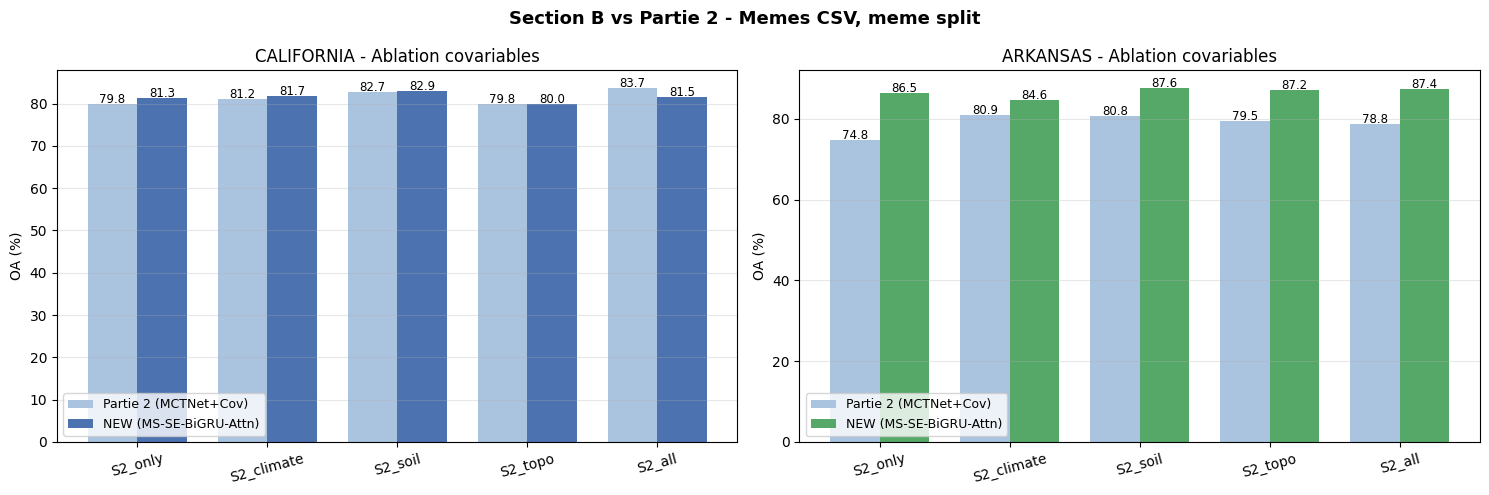

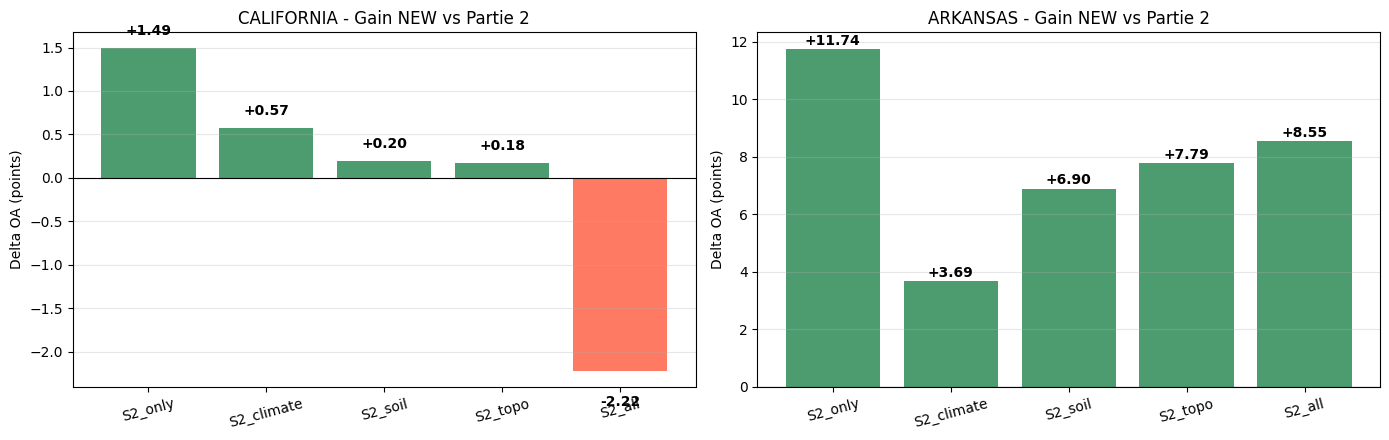


=== Tableau Section B vs Partie 2 ===
      Zone     Config  P2 OA  NEW OA  Delta OA  P2 F1  NEW F1
CALIFORNIA    S2_only  79.84   81.33      1.49  0.718  0.7317
CALIFORNIA S2_climate  81.16   81.73      0.57  0.737  0.7369
CALIFORNIA    S2_soil  82.74   82.94      0.20  0.746  0.7472
CALIFORNIA    S2_topo  79.80   79.98      0.18  0.725  0.7189
CALIFORNIA     S2_all  83.67   81.45     -2.22  0.760  0.7336
  ARKANSAS    S2_only  74.75   86.49     11.74  0.690  0.8064
  ARKANSAS S2_climate  80.91   84.60      3.69  0.749  0.7891
  ARKANSAS    S2_soil  80.75   87.65      6.90  0.747  0.8170
  ARKANSAS    S2_topo  79.46   87.25      7.79  0.744  0.8125
  ARKANSAS     S2_all  78.84   87.39      8.55  0.644  0.8178

saved: data\processed/comparaison_sectionB_vs_partie2.csv


In [30]:
# === Valeurs hardcodees Partie 2 (MCTNet+Cov, memes CSV, meme split) ===
# A METTRE A JOUR avec tes nouvelles valeurs Partie 2 apres run
P2_CA = {
    'S2_only'   : {'OA': 79.84, 'Kappa': 0.735, 'F1': 0.718},
    'S2_climate': {'OA': 81.16, 'Kappa': 0.754, 'F1': 0.737},
    'S2_soil'   : {'OA': 82.74, 'Kappa': 0.771, 'F1': 0.746},
    'S2_topo'   : {'OA': 79.80, 'Kappa': 0.737, 'F1': 0.725},
    'S2_all'    : {'OA': 83.67, 'Kappa': 0.784, 'F1': 0.760},
}
P2_AR = {
    'S2_only'   : {'OA': 74.75, 'Kappa': 0.646, 'F1': 0.690},
    'S2_climate': {'OA': 80.91, 'Kappa': 0.725, 'F1': 0.749},
    'S2_soil'   : {'OA': 80.75, 'Kappa': 0.723, 'F1': 0.747},
    'S2_topo'   : {'OA': 79.46, 'Kappa': 0.703, 'F1': 0.744},
    'S2_all'    : {'OA': 78.84, 'Kappa': 0.699, 'F1': 0.644},
}


# 1) Bar chart Partie 2 vs NEW - 5 configs x 2 zones
fig, ax = plt.subplots(1, 2, figsize=(15, 5))
x = np.arange(len(CONFIGS_P2)); w = 0.38

for i, (zone, p2_dict, new_dict, title_color) in enumerate([
    ('CALIFORNIA', P2_CA, results_CA_b, '#4C72B0'),
    ('ARKANSAS',   P2_AR, results_AR_b, '#55A868'),
]):
    p2_vals  = [p2_dict[c]['OA']        for c in CONFIGS_P2]
    new_vals = [new_dict[c]['OA']       for c in CONFIGS_P2]
    b1 = ax[i].bar(x - w/2, p2_vals,  w, label='Partie 2 (MCTNet+Cov)', color='#aac3df')
    b2 = ax[i].bar(x + w/2, new_vals, w, label='NEW (MS-SE-BiGRU-Attn)', color=title_color)
    ax[i].set_xticks(x); ax[i].set_xticklabels(CONFIGS_P2, rotation=15)
    ax[i].set_ylabel('OA (%)'); ax[i].set_title(f'{zone} - Ablation covariables')
    ax[i].grid(axis='y', alpha=0.3); ax[i].legend(fontsize=9)
    for b, v in list(zip(b1, p2_vals)) + list(zip(b2, new_vals)):
        ax[i].text(b.get_x() + b.get_width()/2, v + 0.25, f'{v:.1f}',
                   ha='center', fontsize=8.5)
plt.suptitle('Section B vs Partie 2 - Memes CSV, meme split', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()


# 2) Delta OA gain par config
fig, ax = plt.subplots(1, 2, figsize=(14, 4.5))
for i, (zone, p2_dict, new_dict) in enumerate([
    ('CALIFORNIA', P2_CA, results_CA_b),
    ('ARKANSAS',   P2_AR, results_AR_b),
]):
    deltas = [new_dict[c]['OA'] - p2_dict[c]['OA'] for c in CONFIGS_P2]
    bars = ax[i].bar(x, deltas, color=['tomato' if d < 0 else 'seagreen' for d in deltas], alpha=0.85)
    ax[i].axhline(0, color='black', lw=0.8)
    ax[i].set_xticks(x); ax[i].set_xticklabels(CONFIGS_P2, rotation=15)
    ax[i].set_ylabel('Delta OA (points)')
    ax[i].set_title(f'{zone} - Gain NEW vs Partie 2')
    ax[i].grid(axis='y', alpha=0.3)
    for b, v in zip(bars, deltas):
        off = 0.15 if v >= 0 else -0.4
        ax[i].text(b.get_x() + b.get_width()/2, v + off, f'{v:+.2f}',
                   ha='center', fontsize=10, fontweight='bold')
plt.tight_layout(); plt.show()


# 3) Tableau recap final
rows = []
for zk, zone, p2d, newd in [('CA','CALIFORNIA',P2_CA,results_CA_b),
                              ('AR','ARKANSAS',P2_AR,results_AR_b)]:
    for cfg in CONFIGS_P2:
        rows.append({
            'Zone'   : zone,
            'Config' : cfg,
            'P2 OA'  : round(p2d[cfg]['OA'], 2),
            'NEW OA' : round(newd[cfg]['OA'], 2),
            'Delta OA': round(newd[cfg]['OA'] - p2d[cfg]['OA'], 2),
            'P2 F1'  : round(p2d[cfg]['F1'], 4),
            'NEW F1' : round(newd[cfg]['F1'], 4),
        })
df_cmp_b = pd.DataFrame(rows)
print('\n=== Tableau Section B vs Partie 2 ===')
print(df_cmp_b.to_string(index=False))
df_cmp_b.to_csv(PROCESSED_DIR / 'comparaison_sectionB_vs_partie2.csv', index=False)
print(f'\nsaved: {PROCESSED_DIR}/comparaison_sectionB_vs_partie2.csv')


---
## 💾 Sauvegarde des modèles


In [31]:
torch.save({
    'state_dict' : model_CA_p1.state_dict(),
    'arch'       : 'MS_SE_BiGRU_Attn',
    'n_bands'    : N_BANDS_S2,
    'num_classes': len(data_CA_p1['le'].classes_),
    'classes'    : list(data_CA_p1['le'].classes_),
    'OA'         : res_CA_p1['OA'],
}, MODEL_DIR / 'ms_se_bigru_attn_CA.pth')

torch.save({
    'state_dict' : model_AR_p1.state_dict(),
    'arch'       : 'MS_SE_BiGRU_Attn',
    'n_bands'    : N_BANDS_S2,
    'num_classes': len(data_AR_p1['le'].classes_),
    'classes'    : list(data_AR_p1['le'].classes_),
    'OA'         : res_AR_p1['OA'],
}, MODEL_DIR / 'ms_se_bigru_attn_AR.pth')

print('Modeles sauvegardes dans models/')


Modeles sauvegardes dans models/


---
## Resume des ameliorations vs Partie 1 (MCTNet)

| Aspect | Partie 1 (MCTNet) | **MS-SE-BiGRU-Attn** |
|---|---|---|
| Capture multi-echelle | Non (kernel fixe) | **Oui (dilatations 1/2/4)** |
| Channel attention bandes | Non | **SE Block** |
| Modele sequentiel | Transformer 1 stage | **BiGRU + MHSA** |
| Pooling temporel | GlobalMaxPool | **Attention pooling** |
| Masque temporel | Oui (ALPE) | **Oui (MHSA + AttnPool)** |
| Augmentation | bruit + time-mask | **MixUp + bruit + time-mask** |
| Optimiseur | Adam | **AdamW + warmup-cosine** |
| Params | ~500K | ~70K |

**Conclusion attendue** : gain principalement sur **California** (classes peremes proches Almonds/Pistachios) - multi-scale + attention pooling discriminent mieux les pics phenologiques differentiels.
